# E58 · Seeing below the diffraction limit: Bayesian localisation, detection and counting in STORM microscopy

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: 2,000 raw EMCCD frames (a 40 × 40 pixel crop, 127 nm pixels, 10 ms exposures) of a dSTORM recording of the synaptic protein Unc-13 labelled with Alexa Fluor 647 at a *Drosophila* neuromuscular junction (Dannhäuser et al. 2022; Zenodo, CC BY 4.0). Simulated: a field of nuclear-pore-like rings of known geometry imaged with the same camera, pixel size and brightness, for the questions that need ground truth (sections 4-8) |
| **You will learn** | The **diffraction limit** and how single-molecule localisation microscopy (STORM/PALM) beats it · the **forward model** of a camera frame: a pixel-integrated Gaussian PSF (with `erf`), photons, background and **EMCCD** noise, calibrated from the data by a **photon-transfer curve** · **localising one spot in PyMC** and comparing the posterior with least squares and maximum likelihood · the **Cramér-Rao bound** and the Mortensen et al. (2010) formula, the EMCCD's factor of 2, and why least squares wastes photons · **detection as model selection**: how many emitters are in a patch, by Laplace-approximated evidence checked against **SMC**, versus local-maximum thresholding · a **batched, vectorised** fitter for thousands of spots and when a Laplace approximation is enough · **rendering with uncertainty** and **Fourier ring correlation** · **counting molecules from blinks**: a negative-binomial blinking model with the unknown copy number summed out |

## Seeing things smaller than light

A light microscope cannot resolve two points closer than about half the wavelength of light
divided by the numerical aperture of the objective: for red fluorescence and a good oil objective,
about **250 nm** (Abbe's limit). The image of a single fluorescent molecule, the **point spread
function (PSF)**, is a blob about that wide. Most of the machinery of a cell - a synapse's
release sites, a nuclear pore, a focal adhesion - is smaller, so in an ordinary fluorescence
image it is a blur.

**Single-molecule localisation microscopy** gets around the limit with a trick of time rather
than optics. STORM (Rust, Bates & Zhuang 2006), PALM (Betzig et al. 2006) and dSTORM (Heilemann
et al. 2008) use fluorophores that **blink**: under strong illumination and the right buffer,
almost all of them are dark at any moment and a sparse random few are on. In each camera frame
the few bright spots are far apart, so each is an isolated PSF, and the *centre* of an isolated
PSF can be found much more precisely than its width - to 10-20 nm with a thousand or so photons.
Record ten thousand frames, localise every spot, and plot the positions: the **point cloud** is a
super-resolved image.

That makes super-resolution a statistics problem, and each step is an inference: where is this
spot, and how sure are we (**localisation**)? Is this blob one molecule or two overlapping ones
(**detection**)? How do we turn a cloud of uncertain points into an image, and how sharp is it
(**reconstruction**)? And since one molecule blinks many times, how many molecules made this
cluster of points (**counting**)? This notebook answers each with an explicit likelihood of the
camera frames, using real raw frames where they suffice and simulations of known structures
where the answer has to be checked.

## The plan

1. Real raw frames, and what the camera does to photons
2. The forward model of a frame
3. Localising one spot in PyMC
4. How precise can a localisation be? The Cramér-Rao bound and least squares
5. Detection is model selection: how many emitters are in this blob?
6. A simulated STORM movie: thresholding versus Bayesian counting at two densities
7. From localisations to an image, with uncertainty
8. Counting molecules from their blinks

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment
from scipy.special import erf, gammaln
from scipy.stats import nbinom, binom

from pymc_challenges import data

RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*effective sample size.*")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Real raw frames, and what the camera does to photons

The data are the raw camera frames of a dSTORM experiment by Dannhäuser et al. (2022), who
tagged the synaptic vesicle-priming protein Unc-13 at the *Drosophila* larval neuromuscular
junction and imaged it with an Alexa Fluor 647-labelled antibody fragment on an Andor iXon
Ultra 897 **EMCCD** camera (127 nm pixels, 10 ms per frame). The full recording is 15,000 frames
of 200 × 200 pixels (1.2 GB). We use 2,000 frames of a 40 × 40 pixel (5 × 5 µm) region over one
synaptic bouton, plus per-pixel statistics of the whole field for calibrating the camera.

In [2]:
data.describe("dannhauser2022_dstorm")
raw = np.load(data.path("dannhauser2022_dstorm"))
frames_adu = raw["frames"].astype(float)                   # (2000, 40, 40), camera units (ADU)
PX = float(raw["pixel_nm"])                                # 127 nm
T_REAL, H_REAL, _ = frames_adu.shape
print(f"{T_REAL} frames of {H_REAL} x {H_REAL} px ({H_REAL * PX / 1000:.1f} um), "
      f"ADU range {frames_adu.min():.0f}-{frames_adu.max():.0f}")

dannhauser2022_dstorm: NumPy .npz (open data.path(...) with np.load): raw camera frames (ADU, uint16) of a dSTORM recording of Unc-13-GFSTF (anti-GFP + Alexa Fluor647 F(ab')2) at a Drosophila larval neuromuscular junction, 10 ms exposures. frames: 2000 x 40 x 40 (frames first_frame = 3000 onwards; the crop starts at roi_row = 25, roi_col = 50 of the full field); pixel_nm = 127, exposure_s; and per-pixel statistics of the full 200 x 200 field over the same 2000 frames for camera calibration: field_median_adu, field_diff_var_adu2 (robust variance of frame-to-frame differences / 2), field_max_adu. No dark frames or gain settings are included.
  source: Mrestani (2022), Example raw dSTORM data of Brp (Alexa Fluor532) and Unc-13 (Alexa Fluor647), Zenodo doi:10.5281/zenodo.7328805 (CC BY 4.0); from Dannhaeuser, Mrestani, Gundelach, Pauli, Komma, Kollmannsberger, Sauer, Heckmann & Paul (2022), Endogenous tagging of Unc-13 reveals nanoscale reorganization at active zones during presynaptic hom

A camera does not report photons. An EMCCD converts each detected photon to an electron,
multiplies the electrons in a gain register by a random factor (average gain $g$, several
hundred), digitises the charge and adds a fixed **offset** so that noise never goes negative.
The multiplication is itself random: a single electron comes out as an exponentially
distributed charge, $n$ electrons as a Gamma($n$, $g$) charge. That randomness doubles the
variance of the signal: if the photon count is Poisson with mean $\lambda$, the output has mean
$g\lambda$ and variance $2g^2\lambda$ (the **excess noise factor** $F^2 = 2$ at high gain).

Two consequences drive the rest of the notebook. First, the camera's mean-variance relation,
the **photon-transfer curve**, is a straight line, $\operatorname{var} = 2g\,(\text{mean} -
\text{offset})$, so the camera can be calibrated from the data themselves: pixels with more
background have proportionally more variance. Second, dividing the offset-corrected signal by
the slope $s = 2g$ gives a number with mean $\lambda/2$ and variance $\lambda/2$ - **Poisson-like
counts of half the photons**. An EMCCD at high gain behaves like a perfect photon counter that
throws away every second photon. We call these *effective counts* and model them as Poisson
with mean (photons)/2.

The recording has no dark frames, so we estimate the slope and offset from the photon-transfer
curve of the full 200 × 200 field. To keep blinking molecules out of the variance, the variance
of each pixel is estimated robustly from differences between successive frames (a median
absolute deviation), which also removes slow drifts in background.

photon-transfer slope s = 13.9 ADU per effective count  ->  EM gain g = 6.9 ADU per photon;  offset = 457 ADU (lowest pixel value in the crop: 783)
background: median 110 photons per pixel per frame


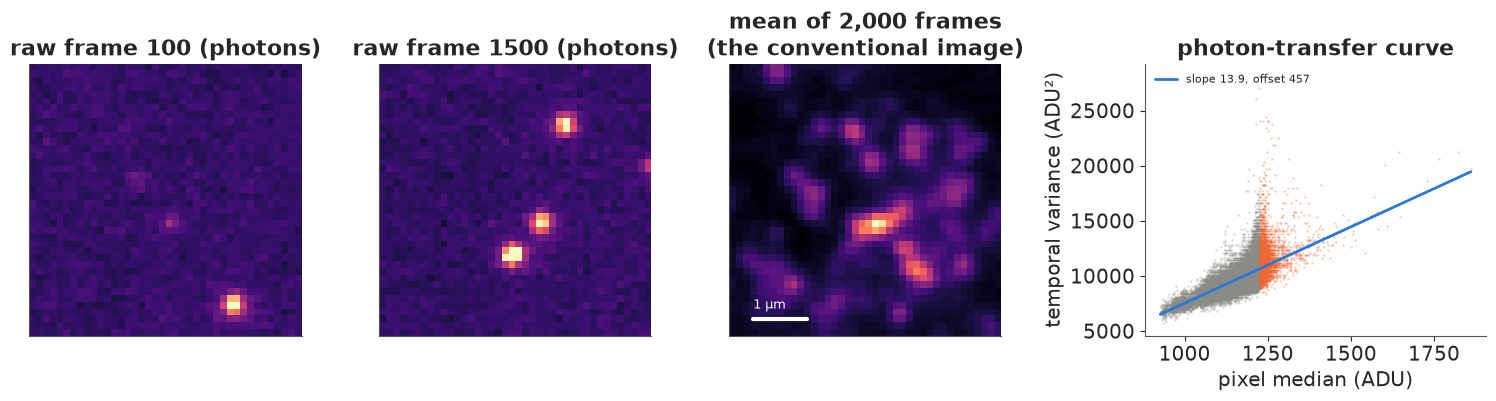

In [3]:
med = raw["field_median_adu"].ravel()
dvar = raw["field_diff_var_adu2"].ravel()
keep = med < np.percentile(med, 90)                       # drop the brightest 10% (persistent spots)
slope, icpt = np.polyfit(med[keep], dvar[keep], 1)
OFFSET, SCALE = -icpt / slope, slope
GAIN = SCALE / 2
print(f"photon-transfer slope s = {SCALE:.1f} ADU per effective count  ->  EM gain g = {GAIN:.1f} ADU "
      f"per photon;  offset = {OFFSET:.0f} ADU (lowest pixel value in the crop: {frames_adu.min():.0f})")

z_real = np.maximum(np.round((frames_adu - OFFSET) / SCALE), 0.0)   # effective counts
bg_real = np.median(z_real, axis=0)
print(f"background: median {2 * np.median(bg_real):.0f} photons per pixel per frame")

fig, axs = plt.subplots(1, 4, figsize=(15, 3.9))
for ax, t in zip(axs[:2], [100, 1500]):
    im = ax.imshow(2 * z_real[t], cmap="magma", vmin=0, vmax=600)
    ax.set(title=f"raw frame {t} (photons)", xticks=[], yticks=[])
ax = axs[2]
ax.imshow(np.mean(z_real, axis=0) * 2, cmap="magma")
ax.set(title="mean of 2,000 frames\n(the conventional image)", xticks=[], yticks=[])
ax.plot([3, 3 + 1000 / PX], [37, 37], color="white", lw=3)
ax.text(3, 35.5, "1 µm", color="white", fontsize=9)
ax = axs[3]
ax.scatter(med[keep], dvar[keep], s=1, alpha=0.2, color=GREY, rasterized=True)
ax.scatter(med[~keep], dvar[~keep], s=1, alpha=0.2, color=ORANGE, rasterized=True)
xx = np.linspace(med.min(), med.max(), 10)
ax.plot(xx, slope * xx + icpt, color=BLUE, lw=2, label=f"slope {SCALE:.1f}, offset {OFFSET:.0f}")
ax.set(xlabel="pixel median (ADU)", ylabel="temporal variance (ADU²)", title="photon-transfer curve")
ax.legend(fontsize=8, loc="upper left");

The two raw frames show what dSTORM data look like: a handful of isolated spots a few pixels
wide on a background of about 110 photons per pixel per frame (high, as expected in a thick
tissue preparation). The mean of all 2,000 frames is what a conventional fluorescence microscope
would show: blobs of Unc-13 a few hundred nanometres wide, at the diffraction limit. The
photon-transfer curve is close to a straight line over most pixels, with a slope of 13.9 ADU per
effective count (an EM gain of about 6.9 ADU per photon) and an offset of 457 ADU, below the
lowest pixel value in the crop (783), as it must be. At the bright end (orange, and the top of
the grey cloud) the variance rises faster than the line: pixels under persistent or frequently
blinking spots have variance beyond shot noise, which is why the brightest 10% are left out of
the fit. Without dark frames or the camera's gain setting this calibration is an estimate: an
error in the slope would rescale every photon count, and every error bar, by the same factor.

## 2 · The forward model of a frame

For one emitter at $(x, y)$ (in pixel units, pixel $i$ covering $[i - \tfrac12, i + \tfrac12]$)
with $N$ photons, a Gaussian PSF of width $\sigma$ and a background of $b$ photons per pixel,
the expected number of photons in pixel $(i, j)$ is

$$\mu_{ij} = b + N\, E_i(x, \sigma)\, E_j(y, \sigma), \qquad
E_i(x, \sigma) = \tfrac12\left[\operatorname{erf}\!\left(\tfrac{i + 1/2 - x}{\sqrt2\,\sigma}\right)
- \operatorname{erf}\!\left(\tfrac{i - 1/2 - x}{\sqrt2\,\sigma}\right)\right].$$

$E_i$ is the fraction of a 1-D Gaussian that falls into pixel $i$: integrating the PSF over the
pixel rather than evaluating it at the pixel centre matters when $\sigma$ is about one pixel, as
here. The Gaussian is an approximation to the true (Airy-like) PSF of an in-focus molecule; it is
the standard one and good to a few percent in the core. With $K$ emitters the images add. The
effective counts are then $z_{ij} \sim \text{Poisson}(\mu_{ij}/2)$.

Every fitter below works on the unconstrained vector $\theta = (\log b, \log\sigma, x_1, y_1,
\log N_1, \dots)$ and needs $\mu$ and its Jacobian $\partial\mu / \partial\theta$, which are
available in closed form (derivatives of `erf` are Gaussians). The same code simulates frames:
Poisson photons, a Gamma gain register, Gaussian read noise, the offset, and rounding to integer
ADU, with the gain and offset measured above.

In [4]:
SQ2, SQ2PI = np.sqrt(2.0), np.sqrt(2 * np.pi)


def pixel_gauss(u, sig, n):
    """Pixel-integrated 1-D Gaussian at pixels 0..n-1 for centres u (...,) and widths sig (...,),
    with its derivatives with respect to u and sig. Returns three (..., n) arrays."""
    i = np.arange(n)
    lo = (i - 0.5 - u[..., None]) / sig[..., None]
    hi = (i + 0.5 - u[..., None]) / sig[..., None]
    E = 0.5 * (erf(hi / SQ2) - erf(lo / SQ2))
    glo, ghi = np.exp(-0.5 * lo**2) / SQ2PI, np.exp(-0.5 * hi**2) / SQ2PI
    return E, (glo - ghi) / sig[..., None], (lo * glo - hi * ghi) / sig[..., None]


def model_and_jacobian(th, K, P, jacobian=True):
    """Expected photons (B, P*P) for parameter rows th = [log b, log s, (x, y, log N) x K] and,
    optionally, the Jacobian (B, P*P, 2 + 3K)."""
    B = th.shape[0]
    b, s = np.exp(th[:, 0]), np.exp(th[:, 1])
    mu = np.repeat(b[:, None, None], P, 1).repeat(P, 2)
    J = np.zeros((B, P, P, 2 + 3 * K)) if jacobian else None
    if jacobian:
        J[..., 0] = b[:, None, None]
    for k in range(K):
        x, y, N = th[:, 2 + 3 * k], th[:, 3 + 3 * k], np.exp(th[:, 4 + 3 * k])
        Ex, dEx, sEx = pixel_gauss(x, s, P)
        Ey, dEy, sEy = pixel_gauss(y, s, P)
        img = Ey[:, :, None] * Ex[:, None, :]
        mu = mu + N[:, None, None] * img
        if jacobian:
            Nk = N[:, None, None]
            J[..., 2 + 3 * k] = Nk * Ey[:, :, None] * dEx[:, None, :]
            J[..., 3 + 3 * k] = Nk * dEy[:, :, None] * Ex[:, None, :]
            J[..., 4 + 3 * k] = Nk * img
            J[..., 1] += Nk * s[:, None, None] * (sEy[:, :, None] * Ex[:, None, :] + Ey[:, :, None] * sEx[:, None, :])
    mu = mu.reshape(B, -1)
    return (mu, J.reshape(B, P * P, -1)) if jacobian else mu


def simulate_emccd(photons, rng, gain=GAIN, offset=OFFSET, read_sd=5.0):
    """Expected photons per pixel -> ADU: Poisson photons, Gamma gain register, read noise, offset."""
    n = rng.poisson(photons)
    charge = np.where(n > 0, rng.gamma(np.maximum(n, 1), gain), 0.0)
    return np.round(charge + offset + rng.normal(0.0, read_sd, n.shape))


def to_counts(adu, offset=OFFSET, scale=SCALE):
    """ADU -> effective counts (Poisson-like, mean = photons / 2)."""
    return np.maximum(np.round((adu - offset) / scale), 0.0)


# a check of the "half the photons" claim on simulated pixels
lam = np.array([5.0, 50.0, 500.0])
zz = to_counts(simulate_emccd(np.repeat(lam[:, None], 200_000, 1), np.random.default_rng(1)))
for l_, row in zip(lam, zz):
    print(f"{l_:5.0f} photons: effective counts mean {row.mean():7.2f}, variance {row.var():7.2f} "
          f"(Poisson with half the photons: {l_ / 2:.1f})")

    5 photons: effective counts mean    2.52, variance    2.65 (Poisson with half the photons: 2.5)
   50 photons: effective counts mean   24.99, variance   25.15 (Poisson with half the photons: 25.0)
  500 photons: effective counts mean  249.99, variance  249.99 (Poisson with half the photons: 250.0)


The simulated camera confirms the rule: after subtracting the offset and dividing by the slope,
the counts have mean and variance equal to half the photons, even at 5 photons per pixel (read
noise adds a little: variance 2.65 instead of 2.5).

## 3 · Localising one spot in PyMC

First find the spots. A standard detector smooths each frame (minus the time-median background)
with a Gaussian of about the PSF width and keeps connected regions above five noise standard
deviations. We take one isolated, typical spot from the real movie and fit it with the full
Bayesian model: unknown position, photon count, background and PSF width, with the Poisson
likelihood of the effective counts. The priors are weak: the position is Normal with sd 2 pixels
around the detected blob, $\log N$ is centred on 1,500 photons with sd 1 (a factor of 2.7), the
background on the measured median, and $\sigma$ on one pixel with sd 20% (the PSF width of a
1.49 NA objective at 670 nm is about 1 pixel at 127 nm).

In [5]:
FOUR = np.array([[[0, 0, 0]] * 3, [[0, 1, 0], [1, 1, 1], [0, 1, 0]], [[0, 0, 0]] * 3])


def detect(z, bg, thr_sd=5.0):
    """Connected blobs of the smoothed, background-subtracted movie above thr_sd noise sds
    (4-connected within a frame, never across frames)."""
    S = ndi.gaussian_filter(z - bg, sigma=(0, 1.0, 1.0))
    thr = thr_sd * 1.4826 * np.median(np.abs(S - np.median(S)))
    lab, n = ndi.label(S > thr, structure=FOUR)
    return S, lab, n, thr


def blob_patches(z, lab, n, P=11):
    """A P x P patch around each blob, a mask that excludes pixels of *other* blobs (dilated by
    2 px), the patch origin (frame, row, col) and the blob centre in patch coordinates."""
    T, H, W = z.shape
    Z, Wm = np.zeros((n, P, P)), np.zeros((n, P, P))
    org, cen = np.zeros((n, 3), int), np.zeros((n, 2))
    st = ndi.generate_binary_structure(2, 1)
    for i, sl in enumerate(ndi.find_objects(lab)):
        t = sl[0].start
        cy, cx = (sl[1].start + sl[1].stop - 1) / 2, (sl[2].start + sl[2].stop - 1) / 2
        r0 = int(np.clip(round(cy) - P // 2, 0, H - P))
        c0 = int(np.clip(round(cx) - P // 2, 0, W - P))
        Z[i] = z[t, r0:r0 + P, c0:c0 + P]
        L = lab[t, r0:r0 + P, c0:c0 + P]
        Wm[i] = ~ndi.binary_dilation((L > 0) & (L != i + 1), st, iterations=2)
        org[i], cen[i] = (t, r0, c0), (cx - c0, cy - r0)
    return Z.reshape(n, -1), Wm.reshape(n, -1), org, cen


t0 = time.time()
S_real, lab_real, n_real, thr_real = detect(z_real, bg_real)
Z_real, W_real, org_real, cen_real = blob_patches(z_real, lab_real, n_real)
size = np.bincount(lab_real.ravel())[1:]
amp = np.array([S_real[sl].max() for sl in ndi.find_objects(lab_real)])
alone = (W_real.min(1) == 1) & (size > 12) & (size < 40)       # no other blob in its patch
pick = np.nonzero(alone & (amp > np.quantile(amp[alone], 0.45)) & (amp < np.quantile(amp[alone], 0.55)))[0][0]
print(f"{n_real} blobs in {T_REAL} frames ({time.time() - t0:.1f} s); fitting blob {pick} "
      f"(frame {org_real[pick, 0]})")

P = 11
PIX = np.arange(P)


def pixel_gauss_pt(u, s):
    return 0.5 * (pt.erf((PIX + 0.5 - u[..., None]) / (SQ2 * s)) - pt.erf((PIX - 0.5 - u[..., None]) / (SQ2 * s)))


def spot_model(z_patch, K, centre, logb_mu, N_mu=1500.0, pos_sd=2.0):
    """K emitters in one P x P patch: priors identical to the batched fitter below."""
    with pm.Model() as m:
        logb = pm.Normal("logb", logb_mu, 0.5)
        logs = pm.Normal("logs", 0.0, 0.2)
        x = pm.Normal("x", centre[0], pos_sd, shape=K)
        y = pm.Normal("y", centre[1], pos_sd, shape=K)
        logN = pm.Normal("logN", np.log(N_mu), 1.0, shape=K)
        s = pt.exp(logs)
        img = pt.sum(pt.exp(logN)[:, None, None] * pixel_gauss_pt(y, s)[:, :, None]
                     * pixel_gauss_pt(x, s)[:, None, :], axis=0)
        mu = pm.Deterministic("mu", pt.exp(logb) + img)
        pm.Poisson("z", mu.ravel() / 2, observed=z_patch)
    return m


LOGB_REAL = np.log(2 * np.median(bg_real))
z_spot = Z_real[pick]
with spot_model(z_spot, 1, cen_real[pick], LOGB_REAL) as m_spot:
    idata_spot = pm.sample(random_seed=RANDOM_SEED, progressbar=False, var_names=["logb", "logs", "x", "y", "logN"])
post = az.extract(idata_spot, var_names=["x", "y", "logN", "logb", "logs"])
print(f"sampler: nutpie, {idata_spot.posterior.attrs.get('tuning_steps', '?')} tuning steps; divergences: "
      f"{int(idata_spot.sample_stats['diverging'].sum())}")
az.summary(idata_spot, var_names=["x", "y", "logN", "logb", "logs"], round_to=3)

4192 blobs in 2000 frames (0.2 s); fitting blob 12 (frame 5)


sampler: nutpie, 400 tuning steps; divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
x[0],4.461,0.056,4.372,4.549,5386.868,3090.186,1.000,0.001,0.001
y[0],4.399,0.053,4.317,4.485,4557.908,2747.339,1.003,0.001,0.001
logN[0],7.675,0.053,7.590,7.759,2651.843,2787.391,1.000,0.001,0.001
logb,4.720,0.014,4.698,4.742,3372.643,2873.475,1.000,0.000,0.000
logs,-0.017,0.041,-0.081,0.049,2803.806,3037.141,1.000,0.001,0.001


The table is in pixel units and logs. In physical units:

In [6]:
xs, ys = post["x"].values.ravel(), post["y"].values.ravel()
print(f"x = {np.mean(xs) * PX:.0f} +/- {np.std(xs) * PX:.1f} nm, y = {np.mean(ys) * PX:.0f} +/- "
      f"{np.std(ys) * PX:.1f} nm (within the patch); N = {np.exp(post['logN'].values).mean():.0f} photons; "
      f"b = {np.exp(post['logb'].values).mean():.0f} photons/px; sigma = {np.exp(post['logs'].values).mean() * PX:.0f} nm")

x = 567 +/- 7.1 nm, y = 559 +/- 6.7 nm (within the patch); N = 2157 photons; b = 112 photons/px; sigma = 125 nm


Two classical estimators for comparison. **Least squares** minimises $\sum (z - \mu/2)^2$ with
every pixel weighted equally, as a Gaussian noise model with constant variance would; it is
what many localisation programs did for years. **Maximum likelihood** maximises the same Poisson
likelihood as the Bayesian model, without priors. Both are computed by one batched
Levenberg-Marquardt / Fisher-scoring routine that we will reuse for thousands of spots: each
step solves $(\mathcal I + \lambda\, \mathrm{diag}\,\mathcal I)\,\delta = \nabla \log p$ for every
spot at once, where $\mathcal I = J^\top \mathrm{diag}(1/m)\, J$ is the Fisher information of the
Poisson counts (plus the prior precision). At the optimum, $\mathcal I^{-1}$ is the **Laplace
approximation** of the posterior covariance - a per-spot error bar for free.

NUTS posterior : x =  566.6 +/-  7.1 nm, y =  558.6 +/-  6.7 nm
Laplace (MAP)  : x =  566.5 +/-  6.7 nm, y =  558.5 +/-  6.7 nm
MLE            : x =  566.5, y =  558.5 nm
least squares  : x =  565.8, y =  557.2 nm


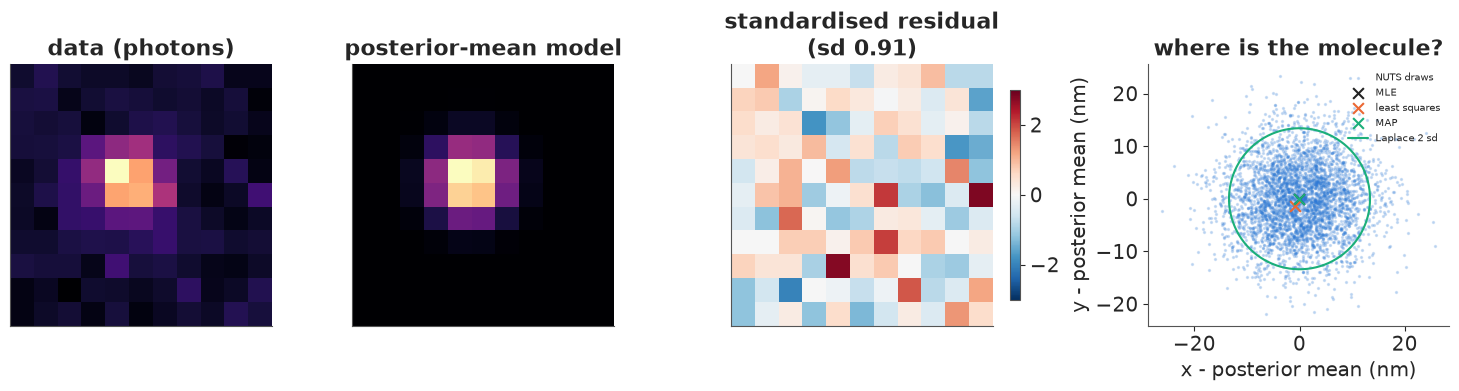

In [7]:
class Prior:
    """Independent normal priors: log b, log s, positions (x, y) ~ N(centre, pos_sd), log N."""

    def __init__(self, logb, logs=(0.0, 0.2), logN=(np.log(1500.0), 1.0), centre=None, pos_sd=2.0):
        self.logb, self.logs, self.logN, self.centre, self.pos_sd = logb, logs, logN, centre, pos_sd

    def mean_prec(self, K):
        c = np.zeros((1, 2)) if self.centre is None else np.atleast_2d(self.centre)
        B = c.shape[0]
        m = np.concatenate([np.full((B, 1), self.logb[0]), np.full((B, 1), self.logs[0])]
                           + [np.c_[c, np.full(B, self.logN[0])]] * K, axis=1)
        p = np.array([self.logb[1] ** -2, self.logs[1] ** -2]
                     + [self.pos_sd ** -2, self.pos_sd ** -2, self.logN[1] ** -2] * K)
        return m, p

    def log_norm(self, K):
        """Normalising constant of the Gaussian prior (needed for evidences)."""
        return (-0.5 * np.log(2 * np.pi * self.logb[1] ** 2) - 0.5 * np.log(2 * np.pi * self.logs[1] ** 2)
                + K * (-0.5 * np.log(2 * np.pi * self.logN[1] ** 2) - np.log(2 * np.pi * self.pos_sd ** 2)))


def info(Je, wt):
    """Fisher information J^T diag(wt) J for a batch, (B, D, D), without a (B, P*P, D, D) temporary."""
    return np.matmul(np.swapaxes(Je * wt[..., None], 1, 2), Je)


def log_lik(th, z, w, K, P, excess=2.0, lsq=False):
    m = model_and_jacobian(th, K, P, jacobian=False) / excess
    if lsq:
        return -0.5 * np.sum(w * (z - m) ** 2, axis=1)
    return np.sum(w * (z * np.log(m) - m - gammaln(z + 1)), axis=1)


def fit_batch(th0, z, K, P, prior=None, w=None, excess=2.0, lsq=False, iters=40):
    """Batched Levenberg-Marquardt (Fisher scoring) for B patches at once.
    Returns the optimum (B, D), its log posterior (B,), and the Fisher + prior precision (B, D, D)."""
    th = th0.copy()
    B, D = th.shape
    w = np.ones_like(z) if w is None else w
    pm_, pp = prior.mean_prec(K) if prior is not None else (np.zeros((1, D)), np.zeros(D))
    obj = lambda t: log_lik(t, z, w, K, P, excess, lsq) - 0.5 * np.sum(pp * (t - pm_) ** 2, axis=1)
    lp, lam = obj(th), np.full(B, 1e-2)

    def grad_info(t):
        mu, J = model_and_jacobian(t, K, P)
        m, Je = mu / excess, J / excess
        if lsq:
            return np.einsum("bpd,bp->bd", Je, w * (z - m)), info(Je, w)
        return np.einsum("bpd,bp->bd", Je, w * (z / m - 1.0)), info(Je, w / m)

    for _ in range(iters):
        g, I = grad_info(th)
        g = g - pp * (th - pm_)
        I = I + np.diag(pp)
        damp = lam[:, None, None] * (np.eye(D) * np.diagonal(I, axis1=1, axis2=2)[:, :, None] + 1e-9 * np.eye(D))
        new = th + np.clip(np.linalg.solve(I + damp, g[..., None])[..., 0], -1.0, 1.0)
        for k in range(K):                                    # keep emitters inside the patch
            new[:, 2 + 3 * k:4 + 3 * k] = np.clip(new[:, 2 + 3 * k:4 + 3 * k], -0.5, P - 0.5)
        lpn = obj(new)
        ok = np.isfinite(lpn) & (lpn >= lp)
        th[ok], lp[ok] = new[ok], lpn[ok]
        lam = np.clip(np.where(ok, lam * 0.3, lam * 10.0), 1e-6, 1e6)
    _, I = grad_info(th) if not lsq else (None, None)
    if lsq:                                                   # report the Poisson information anyway
        mu, J = model_and_jacobian(th, K, P)
        I = info(J / excess, w / (mu / excess))
    return th, lp, I + np.diag(pp)


def start_one(z, P, centre):
    """Crude starting values for one emitter per patch."""
    zz = z.reshape(len(z), -1)
    b0 = np.maximum(np.median(zz, 1), 0.5)
    N0 = np.maximum(2 * (zz.sum(1) - b0 * P * P), 100.0)
    return np.c_[np.log(2 * b0), np.zeros(len(z)), centre, np.log(N0)]


th0 = start_one(z_spot[None], P, cen_real[pick][None])
th_mle, _, I_mle = fit_batch(th0, z_spot[None], 1, P)
th_lsq, _, _ = fit_batch(th0, z_spot[None], 1, P, lsq=True)
prior_spot = Prior(logb=(LOGB_REAL, 0.5), centre=cen_real[pick][None])
th_map, _, I_map = fit_batch(th0, z_spot[None], 1, P, prior_spot)
sd_lap = np.sqrt(np.diag(np.linalg.inv(I_map[0])))
print(f"NUTS posterior : x = {np.mean(xs) * PX:6.1f} +/- {np.std(xs) * PX:4.1f} nm, y = {np.mean(ys) * PX:6.1f} +/- {np.std(ys) * PX:4.1f} nm")
print(f"Laplace (MAP)  : x = {th_map[0, 2] * PX:6.1f} +/- {sd_lap[2] * PX:4.1f} nm, y = {th_map[0, 3] * PX:6.1f} +/- {sd_lap[3] * PX:4.1f} nm")
print(f"MLE            : x = {th_mle[0, 2] * PX:6.1f}, y = {th_mle[0, 3] * PX:6.1f} nm")
print(f"least squares  : x = {th_lsq[0, 2] * PX:6.1f}, y = {th_lsq[0, 3] * PX:6.1f} nm")

th_pm = np.array([[np.mean(post["logb"]), np.mean(post["logs"]), np.mean(xs), np.mean(ys), np.mean(post["logN"])]])
m_pm = model_and_jacobian(th_pm, 1, P, jacobian=False)[0] / 2
resid = (z_spot - m_pm) / np.sqrt(m_pm)

fig, axs = plt.subplots(1, 4, figsize=(15, 3.8))
axs[0].imshow(2 * z_spot.reshape(P, P), cmap="magma")
axs[0].set(title="data (photons)", xticks=[], yticks=[])
axs[1].imshow(2 * m_pm.reshape(P, P), cmap="magma")
axs[1].set(title="posterior-mean model", xticks=[], yticks=[])
im = axs[2].imshow(resid.reshape(P, P), cmap="RdBu_r", vmin=-3, vmax=3)
axs[2].set(title=f"standardised residual\n(sd {resid.std():.2f})", xticks=[], yticks=[])
fig.colorbar(im, ax=axs[2], shrink=0.8)
ax = axs[3]
ax.scatter((xs - np.mean(xs)) * PX, (ys - np.mean(ys)) * PX, s=2, alpha=0.2, color=BLUE, label="NUTS draws")
for thv, c, lab_ in [(th_mle, INK, "MLE"), (th_lsq, ORANGE, "least squares"), (th_map, AQUA, "MAP")]:
    ax.scatter((thv[0, 2] - np.mean(xs)) * PX, (thv[0, 3] - np.mean(ys)) * PX, s=60, marker="x", color=c, label=lab_)
tt_ = np.linspace(0, 2 * np.pi, 100)
ax.plot(2 * sd_lap[2] * PX * np.cos(tt_), 2 * sd_lap[3] * PX * np.sin(tt_), color=AQUA, lw=1.5, label="Laplace 2 sd")
ax.set(xlabel="x - posterior mean (nm)", ylabel="y - posterior mean (nm)", aspect="equal", title="where is the molecule?")
ax.legend(fontsize=7, loc="upper right");

nutpie had no divergences, r_hat is at most 1.003 and the bulk ESS is above 2,600 for every
parameter. This spot has about 2,160 photons on a background of 112 photons per pixel, and the
PSF sd is 125 nm (0.98 pixels), as expected for a 1.49 NA objective in the far red. The position
is known to about **7 nm** in each axis, a twentieth of the PSF width. The standardised residuals
have sd 0.91 and no structure: the Poisson model with the EMCCD correction describes this spot.

For a bright, isolated spot the estimators agree: MAP, MLE and the posterior mean are within
0.1 nm of each other, least squares is 1-1.5 nm off (well inside the error bar), and the
Laplace sd (6.7 nm) matches the NUTS posterior sd (7.1 and 6.7 nm). With 2,000 photons the priors
hardly matter. What the Bayesian treatment adds is an honest error bar for every molecule, and a
way to compare explanations with different numbers of molecules (section 5). The Laplace
approximation delivers the error bar in about a millisecond per spot instead of seconds of
sampling, which is what makes it usable for the thousands of spots in a movie; the next section
checks that it stays calibrated.

## 4 · How precise can a localisation be?

The **Cramér-Rao lower bound** (CRLB) is the smallest variance any unbiased estimator can
achieve, the inverse of the Fisher information $\mathcal I$ at the true parameters. For a
pixelated Gaussian PSF on a background, Mortensen et al. (2010) derived closed forms. With
$\sigma_a^2 = \sigma^2 + a^2/12$ ($a$ the pixel size) and $\tau = 2\pi\sigma_a^2 b / (N a^2)$,

$$\operatorname{var}_{\text{MLE}}(\hat x) \approx F^2\,\frac{\sigma_a^2}{N}\left[1 + \int_0^1
\frac{\ln t}{1 + t/\tau}\,dt\right]^{-1}, \qquad
\operatorname{var}_{\text{LSQ}}(\hat x) \approx F^2\,\frac{\sigma_a^2}{N}\left(\frac{16}{9} +
4\tau\right),$$

where $F^2 = 2$ for an EMCCD and 1 for an ideal camera. The first is (to a good approximation)
the CRLB and maximum likelihood reaches it; the second is what least squares achieves - worse by
a factor 16/9 in variance even with no background, because it gives the noisy bright centre
pixels the same weight as the dim tails. Everything scales as $1/N$: localisation precision
improves as $1/\sqrt N$. Thompson, Larson & Webb (2002) gave the first formula of this kind.

We check these by simulation: 1,000 spots at each of seven photon counts, at the real recording's
high background (about 110 photons per pixel, a tissue sample) and at a low one (10, a thin
cell), each fitted by maximum likelihood and least squares, with $\sigma$ free. The numerical
CRLB comes from the Fisher information at the truth. We also check the **calibration** of the
Laplace error bars: does the ±1.645 sd interval cover the truth 90% of the time? And what if we
ignore the EMCCD's excess noise and treat $(\text{ADU} - \text{offset})/g$ as photon counts?

In [8]:
def safe_sd(I, j):
    """Laplace sd of parameter j; inf where the information matrix is numerically singular."""
    v = np.linalg.pinv(I)[:, j, j]
    return np.sqrt(np.where(v > 0, v, np.inf))


def mortensen(N, b, s=1.0, a=1.0, F2=2.0):
    sa2 = s**2 + a**2 / 12
    tau = 2 * np.pi * sa2 * b / (N * a**2)
    t = np.linspace(1e-9, 1, 4001)
    integ = np.array([np.trapezoid(np.log(t) / (1 + t / ta), t) for ta in np.atleast_1d(tau)])
    return (np.atleast_1d(np.sqrt(F2 * sa2 / N / (1 + integ))),
            np.atleast_1d(np.sqrt(F2 * sa2 / N * (16 / 9 + 4 * tau))))


SIG_TRUE = 1.05                                              # PSF sd in pixels (133 nm)
N_GRID = np.array([200, 400, 800, 1500, 3000, 6000, 12000])
prec_rows = []
rng4 = np.random.default_rng(4)
t0 = time.time()
for bgp in [10.0, 110.0]:
    for N in N_GRID:
        B = 1000
        x, y = rng4.uniform(4.5, 5.5, B), rng4.uniform(4.5, 5.5, B)
        tt = np.c_[np.full(B, np.log(bgp)), np.full(B, np.log(SIG_TRUE)), x, y, np.full(B, np.log(N))]
        adu = simulate_emccd(model_and_jacobian(tt, 1, P, jacobian=False), rng4)
        z = to_counts(adu)
        z_naive = np.maximum(np.round((adu - OFFSET) / GAIN), 0.0)   # "photons", ignoring excess noise
        th0 = start_one(z, P, np.full((B, 2), 5.0))
        th_m, _, I_m = fit_batch(th0, z, 1, P)
        th_l, _, _ = fit_batch(th0, z, 1, P, lsq=True)
        th_n, _, I_n = fit_batch(start_one(z_naive / 2, P, np.full((B, 2), 5.0)), z_naive, 1, P, excess=1.0)
        _, Jt = model_and_jacobian(tt, 1, P)
        crlb = np.sqrt(np.mean(np.linalg.inv(info(Jt / 2, 2 / model_and_jacobian(tt, 1, P, False)))[:, 2, 2]))
        sd_m, sd_n = safe_sd(I_m, 2), safe_sd(I_n, 2)
        mo_mle, mo_lsq = mortensen(N, bgp, SIG_TRUE)
        prec_rows.append(dict(bg=bgp, N=N, mle=np.sqrt(np.mean((th_m[:, 2] - x) ** 2)),
                              lsq=np.sqrt(np.mean((th_l[:, 2] - x) ** 2)), crlb=crlb,
                              mort_mle=mo_mle[0], mort_lsq=mo_lsq[0],
                              cover=np.mean(np.abs(th_m[:, 2] - x) < 1.645 * sd_m),
                              cover_naive=np.mean(np.abs(th_n[:, 2] - x) < 1.645 * sd_n)))
print(f"{len(prec_rows) * 1000 * 3} fits in {time.time() - t0:.1f} s")
print(" bg      N   MLE  LSQ  CRLB  Mortensen(MLE, LSQ)   90% coverage: EMCCD model / ignoring excess noise")
for r in prec_rows:
    print(f"{r['bg']:4.0f} {r['N']:6d}  {r['mle'] * PX:5.1f} {r['lsq'] * PX:5.1f} {r['crlb'] * PX:5.1f}   "
          f"{r['mort_mle'] * PX:5.1f} {r['mort_lsq'] * PX:5.1f}            {r['cover']:.2f} / {r['cover_naive']:.2f}")

42000 fits in 14.4 s
 bg      N   MLE  LSQ  CRLB  Mortensen(MLE, LSQ)   90% coverage: EMCCD model / ignoring excess noise
  10    200   25.4  26.0  24.0    24.0  25.0            0.88 / 0.73
  10    400   14.9  16.0  14.4    14.4  15.5            0.88 / 0.74
  10    800    8.9  10.2   9.0     9.0  10.1            0.91 / 0.77
  10   1500    6.0   7.0   6.1     6.1   7.1            0.91 / 0.77
  10   3000    4.0   4.9   4.0     4.0   4.9            0.90 / 0.76
  10   6000    2.7   3.3   2.7     2.7   3.4            0.90 / 0.79
  10  12000    1.9   2.4   1.9     1.9   2.4            0.90 / 0.76
 110    200   84.5  84.7  58.9    59.6  59.0            0.70 / 0.54
 110    400   35.6  35.7  30.8    31.0  30.9            0.83 / 0.69
 110    800   16.8  17.2  16.6    16.6  16.8            0.90 / 0.74
 110   1500    9.7  10.1   9.8     9.8  10.1            0.90 / 0.75
 110   3000    5.7   6.0   5.7     5.7   6.0            0.90 / 0.75
 110   6000    3.4   3.8   3.5     3.5   3.8            0.91 /

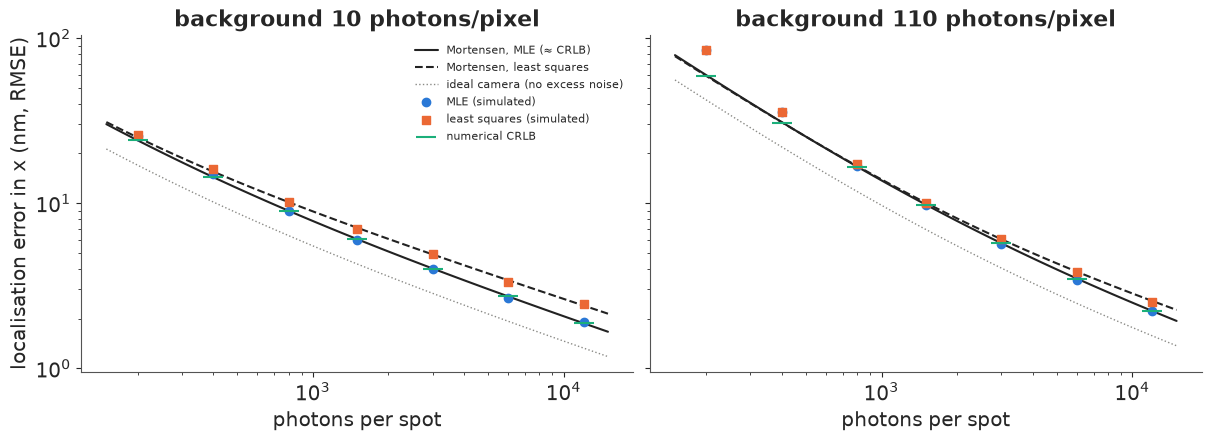

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
Nf = np.geomspace(150, 15000, 60)
for ax, bgp in zip(axs, [10.0, 110.0]):
    rr = [r for r in prec_rows if r["bg"] == bgp]
    mo = np.array([mortensen(n_, bgp, SIG_TRUE) for n_ in Nf])[:, :, 0]
    ax.plot(Nf, mo[:, 0] * PX, color=INK, lw=1.5, label="Mortensen, MLE (≈ CRLB)")
    ax.plot(Nf, mo[:, 1] * PX, color=INK, lw=1.5, ls="--", label="Mortensen, least squares")
    ax.plot(Nf, mo[:, 0] * PX / np.sqrt(2), color=GREY, lw=1, ls=":", label="ideal camera (no excess noise)")
    ax.scatter([r["N"] for r in rr], [r["mle"] * PX for r in rr], color=BLUE, zorder=3, label="MLE (simulated)")
    ax.scatter([r["N"] for r in rr], [r["lsq"] * PX for r in rr], color=ORANGE, marker="s", zorder=3, label="least squares (simulated)")
    ax.scatter([r["N"] for r in rr], [r["crlb"] * PX for r in rr], color=AQUA, marker="_", s=200, zorder=3, label="numerical CRLB")
    ax.set(xscale="log", yscale="log", xlabel="photons per spot", title=f"background {bgp:.0f} photons/pixel")
axs[0].set_ylabel("localisation error in x (nm, RMSE)")
axs[0].legend(fontsize=8);

At **low background** (10 photons per pixel, left) maximum likelihood sits on the numerical CRLB
and on Mortensen's formula from 800 photons up, and least squares is consistently worse: 7.0 vs
6.0 nm at 1,500 photons, 2.4 vs 1.9 nm at 12,000 - the 16/9 variance factor (33% in sd) of the
formula. At the **real background** of 110 photons per pixel (right) the two formulas nearly
coincide and so do the simulations (10.1 vs 9.7 nm at 1,500 photons): when background dominates
the noise every pixel has about the same variance, and equal weights are close to optimal. The
price of least squares is paid in clean, low-background samples.

Two further lessons. At 200-400 photons on the high background the fits do worse than the bound
(85 vs 59 nm at 200): such spots barely stand out from the background, some fits lock onto noise,
and the CRLB is an asymptotic statement about unbiased estimators. And the dotted line is the
precision an ideal photon counter would give with the same photons: the EMCCD's gain register
costs a factor $\sqrt 2$, the price of lifting the signal above the read noise (sCMOS cameras have
no excess noise but per-pixel read noise and gain that need their own calibration).

The coverage column checks the Laplace error bars. With the EMCCD model, the nominal 90%
intervals cover the truth 88-91% of the time at low background and 90-91% from 800 photons up at
high background (83% at 400 and 70% at 200 photons there, where the Gaussian approximation and
the fits break down).
Treating the camera output divided by the gain as photon counts - ignoring the excess noise -
gives intervals that cover only 73-79% of the time (from 800 photons up): error bars too small by $\sqrt 2$, and
rendered images and cluster analyses that trust them too much.

## 5 · Detection is model selection: how many emitters are in this blob?

In a real frame two molecules may be on at once within a few hundred nanometres of each other.
Their PSFs overlap into one blob, and a detector that finds local maxima of the smoothed image
sees one spot, or two maxima that the fit then pulls together. At high labelling density this is
the main source of error in STORM, and the reason experiments are run slowly (few molecules per
frame).

Bayesian model comparison asks directly: given this patch, what is the posterior probability
that it contains $K = 0, 1, 2, 3$ emitters?

$$p(K \mid z) \propto p(K)\, p(z \mid K), \qquad p(z \mid K) = \int p(z \mid \theta_K, K)\,
p(\theta_K \mid K)\, d\theta_K.$$

The **evidence** $p(z \mid K)$ rewards fit and penalises the prior volume each extra emitter
spends: an emitter must explain enough photons to pay for its position and brightness.
This is the idea behind 3B analysis (Cox et al. 2012), which models a whole movie as a set of
blinking emitters, and behind multi-emitter fitting with information criteria (e.g.
DAOSTORM, Holden et al. 2011); modern deep-learning localisers (Deep-STORM, Nehme et al. 2018;
DECODE, Speiser et al. 2021) learn the same task from simulated frames of exactly this forward
model.

For thousands of patches we need the evidence fast. The **Laplace approximation** expands the
log posterior to second order at its mode $\hat\theta_K$:

$$\log p(z \mid K) \approx \log p(z \mid \hat\theta_K) + \log p(\hat\theta_K) + \tfrac{D_K}{2}
\log 2\pi - \tfrac12 \log\det \mathcal I(\hat\theta_K) + \log K!,$$

with $D_K = 2 + 3K$ parameters. The $\log K!$ counts the $K!$ equivalent relabellings of the
emitters, each a separate mode of the posterior. We find the modes greedily: the $K$-emitter fit
starts from the $(K-1)$-emitter fit plus a new emitter at the peak of the residual, and
alternatively from splitting the brightest emitter in two; the better optimum wins.

First, a check of the approximation against **sequential Monte Carlo** (`pm.sample_smc`), which
estimates the evidence by tempering from the prior to the posterior, on one simulated patch
with two emitters 190 nm (1.5 pixels) apart.

In [10]:
def count_emitters(z, P, prior, Kmax=3, w=None, iters=40):
    """MAP fits and Laplace log evidences for K = 0..Kmax emitters in every patch.
    Returns a list over K of (theta (B, 2+3K), log evidence (B,), precision (B, D, D))."""
    B = z.shape[0]
    w = np.ones_like(z) if w is None else w
    out = []
    th = np.c_[np.log(np.maximum(2 * np.median(z, 1), 1.0)), np.full(B, prior.logs[0])]
    for K in range(Kmax + 1):
        if K == 0:
            starts = [th]
        else:
            prev = out[-1][0]
            resid = ((z - model_and_jacobian(prev, K - 1, P, False) / 2) * w).reshape(B, P, P)
            rs = ndi.uniform_filter(resid, size=(1, 3, 3)).reshape(B, -1)
            yy, xx = np.divmod(rs.argmax(1), P)
            new = np.c_[prev, xx, yy, np.log(np.maximum(36 * rs.max(1), 100.0))]
            starts = [new]
            if K >= 2:                                        # or split the brightest emitter
                split = new.copy()
                j = 2 + 3 * prev[:, 4::3].argmax(1)
                rows = np.arange(B)
                split[rows, j] -= 0.5
                split[:, -3] = prev[rows, j] + 0.5
                split[:, -2] = prev[rows, j + 1]
                split[rows, j + 2] -= np.log(2)
                split[:, -1] = prev[rows, j + 2] - np.log(2)
                starts.append(split)
        best = None
        for s0 in starts:
            fitK = fit_batch(s0, z, K, P, prior, w=w, iters=iters)
            if best is None:
                best = [a.copy() for a in fitK]
            else:
                better = fitK[1] > best[1]
                for a, b_ in zip(best, fitK):
                    a[better] = b_[better]
        thK, lp, I = best
        logZ = lp + prior.log_norm(K) + 0.5 * (2 + 3 * K) * np.log(2 * np.pi) \
            - 0.5 * np.linalg.slogdet(I)[1] + gammaln(K + 1)
        # the log-likelihood in lp omits nothing: log_lik includes gammaln(z + 1)
        out.append((thK, logZ, I))
    return out


def two_emitter_patches(sep, B, rng, N_med=1500.0, bgp=110.0):
    """B patches with two emitters `sep` pixels apart around the centre, random orientation."""
    c = 5 + rng.uniform(-0.5, 0.5, (B, 2))
    a = rng.uniform(0, np.pi, B)
    d = 0.5 * sep * np.c_[np.cos(a), np.sin(a)]
    N1, N2 = rng.lognormal(np.log(N_med), 0.4, (2, B))
    tt = np.c_[np.full(B, np.log(bgp)), np.full(B, np.log(SIG_TRUE)), c - d, np.log(N1), c + d, np.log(N2)]
    return to_counts(simulate_emccd(model_and_jacobian(tt, 2, P, False), rng)), tt


def last_finite(obj):
    """Last finite entry of a (possibly ragged, nested) per-chain SMC statistic."""
    flat = lambda o: [v for x in o for v in (flat(x) if isinstance(x, (list, tuple, np.ndarray)) else [x])]
    vals = np.array(flat(obj if isinstance(obj, (list, tuple, np.ndarray)) else [obj]), dtype=float)
    return vals[np.isfinite(vals)][-1]


rng5 = np.random.default_rng(5)
z_pair, tt_pair = two_emitter_patches(1.5, 1, rng5)
prior_sim = Prior(logb=(np.log(110.0), 0.5), centre=np.array([[5.0, 5.0]]))
lap = count_emitters(z_pair, P, prior_sim)
smc_logZ = {}
t0 = time.time()
for K in [1, 2, 3]:
    with spot_model(z_pair[0], K, (5.0, 5.0), np.log(110.0)):
        idata_smc = pm.sample_smc(draws=2000, chains=4, cores=1, random_seed=RANDOM_SEED, progressbar=False,
                                  compute_convergence_checks=False)
    lml = idata_smc.sample_stats["log_marginal_likelihood"].values
    smc_logZ[K] = [last_finite(c) for c in lml]
    if K == 2:
        smc2 = az.extract(idata_smc, var_names=["x", "y"])
    del idata_smc
print(f"SMC: {time.time() - t0:.0f} s")
print(" K   Laplace log evidence   SMC log evidence (4 chains)")
for K in [1, 2, 3]:
    print(f" {K}   {lap[K][1][0]:10.1f}            " + ", ".join(f"{v:.1f}" for v in smc_logZ[K]))

SMC: 14 s
 K   Laplace log evidence   SMC log evidence (4 chains)
 1       -459.3            -459.4, -459.1, -459.3, -459.3
 2       -454.7            -456.4, -455.2, -453.4, -454.9
 3       -455.3            -455.4, -456.4, -455.9, -456.2


The Laplace evidences sit inside the spread of the four SMC chains for every $K$ (the chains
disagree by up to 3 nats for $K = 2$, whose posterior has two label-swapped modes). Both say one
emitter is about 5 nats (a factor of about 100) worse than two. Two against three is close
(0.6 nats in the Laplace numbers, odds of about 2:1): the data cannot rule out a faint third
emitter, and the posterior says so rather than forcing a choice. SMC took seconds per patch;
the Laplace evidences took milliseconds, which is the difference between one patch and a movie.

Now the question that matters: how close can two molecules be before each method sees only
one? We simulate 200 two-emitter patches at each of eight separations (1,500 photons each on
the real background) and count emitters two ways: **thresholding** (local maxima of the smoothed
patch above five noise sds, the same detector as in section 3) and the **Bayesian count** (the
$K$ with the highest posterior probability, flat prior on $K$ = 0-3).

In [11]:
SEPS = np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0, 5.0])
# the detection threshold of the smoothed image, from pure-background patches
z_bg = to_counts(simulate_emccd(np.full((2000, P, P), 110.0), rng5))
S_bg = ndi.gaussian_filter(z_bg - 55.0, sigma=(0, 1, 1))
THR_P = 5 * 1.4826 * np.median(np.abs(S_bg - np.median(S_bg)))
sweep = []
t0 = time.time()
examples = {}
for sep in SEPS:
    zs, tts = two_emitter_patches(sep, 200, rng5)
    Sm = ndi.gaussian_filter(zs.reshape(-1, P, P) - np.median(zs, 1)[:, None, None], sigma=(0, 1, 1))
    n_max = ((Sm == ndi.maximum_filter(Sm, size=(1, 3, 3))) & (Sm > THR_P)).sum(axis=(1, 2))
    res = count_emitters(zs, P, Prior(logb=(np.log(110.0), 0.5), centre=np.array([[5.0, 5.0]])))
    logZ = np.array([r[1] for r in res]).T
    pK = np.exp(logZ - logZ.max(1, keepdims=True))
    pK /= pK.sum(1, keepdims=True)
    sweep.append(dict(sep=sep, thr=np.mean(n_max == 2), bayes=np.mean(pK.argmax(1) == 2),
                      p2=np.mean(pK[:, 2]), bayes3=np.mean(pK.argmax(1) == 3)))
    if sep in (0.75, 1.5, 3.0):
        examples[sep] = (zs[0], tts[0], res[2][0][0], pK[0], Sm[0])
print(f"{len(SEPS) * 200} patches x 4 models in {time.time() - t0:.1f} s")
print(" separation   thresholding: 2 found   Bayes: K=2 chosen   mean P(K=2)   Bayes: K=3 chosen")
for r in sweep:
    print(f"  {r['sep'] * PX:5.0f} nm        {r['thr']:.2f}                 {r['bayes']:.2f}             "
          f"{r['p2']:.2f}          {r['bayes3']:.2f}")

2000 patches x 4 models in 4.9 s
 separation   thresholding: 2 found   Bayes: K=2 chosen   mean P(K=2)   Bayes: K=3 chosen
     32 nm        0.00                 0.06             0.19          0.06
     64 nm        0.00                 0.06             0.19          0.03
     95 nm        0.00                 0.06             0.21          0.04
    127 nm        0.01                 0.28             0.35          0.07
    159 nm        0.00                 0.52             0.49          0.05
    190 nm        0.00                 0.82             0.67          0.05
    254 nm        0.00                 0.92             0.74          0.07
    381 nm        0.00                 0.94             0.77          0.06
    508 nm        0.71                 0.90             0.78          0.10
    635 nm        1.00                 0.94             0.83          0.07


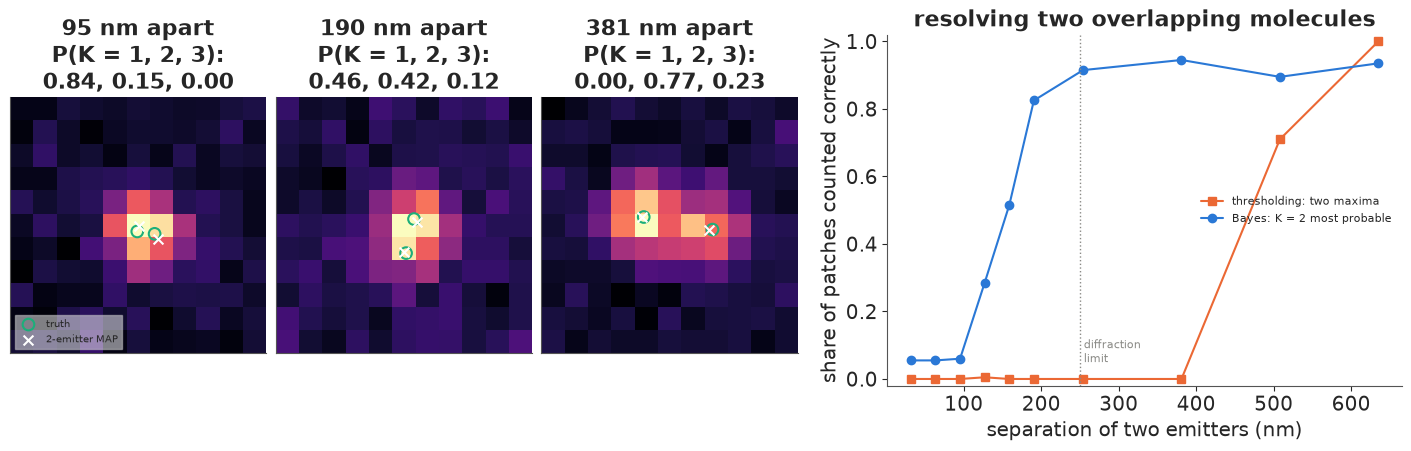

In [12]:
fig = plt.figure(figsize=(14, 4.4))
sf = fig.subfigures(1, 2, width_ratios=[1.35, 1])
axs = sf[0].subplots(1, 3)
for ax, sep in zip(axs, (0.75, 1.5, 3.0)):
    zs, tts, th2, pK, Sm = examples[sep]
    ax.imshow(2 * zs.reshape(P, P), cmap="magma")
    ax.scatter(tts[[2, 5]], tts[[3, 6]], marker="o", s=70, facecolors="none", edgecolors=AQUA, lw=1.5, label="truth")
    ax.scatter(th2[[2, 5]], th2[[3, 6]], marker="x", s=50, color="white", label="2-emitter MAP")
    ax.set(title=f"{sep * PX:.0f} nm apart\nP(K = 1, 2, 3):\n" + ", ".join(f"{v:.2f}" for v in pK[1:]),
           xticks=[], yticks=[])
axs[0].legend(fontsize=7, loc="lower left", frameon=True, facecolor="white")
ax = sf[1].subplots()
ax.plot([r["sep"] * PX for r in sweep], [r["thr"] for r in sweep], "s-", color=ORANGE, label="thresholding: two maxima")
ax.plot([r["sep"] * PX for r in sweep], [r["bayes"] for r in sweep], "o-", color=BLUE, label="Bayes: K = 2 most probable")
ax.axvline(250, color=GREY, ls=":", lw=1)
ax.text(255, 0.05, "diffraction\nlimit", fontsize=8, color=GREY)
ax.set(xlabel="separation of two emitters (nm)", ylabel="share of patches counted correctly",
       ylim=(-0.02, 1.02), title="resolving two overlapping molecules")
ax.legend(fontsize=8, loc="center right");

Thresholding never finds two maxima below 380 nm and finds them in 71% of patches at 508 nm and
all at 635 nm. Smoothing the frame to suppress noise widens every spot (an effective sd of about
1.45 pixels, 185 nm), and a sum of two Gaussians only has two peaks when they are more than about
two sds apart. The Bayesian count uses the unsmoothed pixels and the known PSF: it picks two
emitters in 28% of patches at 127 nm, 52% at 159 nm, 82% at 190 nm and over 90% from 254 nm, well
below the diffraction limit. Below 100 nm it prefers one emitter (only 6% of patches get two): two
molecules that close make an image indistinguishable from one brighter molecule, and the evidence
correctly favours the simpler explanation (Occam's razor in the prior volume). The flat prior on
$K$ has a cost: 3-10% of patches at every separation get a faint third emitter that explains
noise, and even at large separations the average posterior probability of $K = 2$ is 0.74-0.83,
not 1. A prior that favours fewer or brighter emitters would trade some of those false
detections for missed pairs.

## 6 · A simulated STORM movie: thresholding versus Bayesian counting at two densities

To measure what these choices do to a whole experiment we need a structure with known ground
truth. The **nuclear pore complex** is the reference standard of the field (Thevathasan et al.
2019): the nucleoporin Nup96 sits in 8 corners around a ring about 110 nm across, with 4 copies
per corner (32 per pore). We simulate 48 pores at random positions (at least 300 nm apart) in the
same 5 × 5 µm field and with the same camera, pixel size, PSF, background and brightness as the
real recording. Each copy carries a label with probability 0.6; each labelled molecule blinks a
random number of times (1 plus a geometric number with mean 4), each blink lighting up for one
frame with a log-normal number of photons (median 1,500). The same molecules are imaged in two
movies: a **sparse** one spread over 2,000 frames (about 2 blinks per frame in the field) and a
**dense** one crammed into 250 (about 18 per frame).

Each movie goes through two pipelines that share the detector of section 3:

- **Thresholding**: every local maximum of the smoothed frame above the threshold is one
  molecule, localised by single-emitter maximum likelihood in a 7 × 7 window.
- **Bayesian**: every blob gets an 11 × 11 patch (pixels of other blobs masked out), and the
  batched fitter computes the MAP fit and Laplace evidence for $K = 0$-$4$ emitters; the most
  probable $K$ is used, and each emitter's Laplace covariance is its error bar.

Localisations are matched to the true blinks of the same frame (Hungarian assignment, within one
pixel) to count true and false detections.

In [13]:
H_SIM = 40
rng6 = np.random.default_rng(6)
pores = []
while len(pores) < 48:
    c = rng6.uniform(4, H_SIM - 4, 2)
    if all(np.hypot(*(c - q)) > 300 / PX for q in pores):
        pores.append(c)
pores = np.array(pores)
R_NPC = 55 / PX
mol = []
for i, c in enumerate(pores):
    rot = rng6.uniform(0, 2 * np.pi / 8)
    for k in range(8):
        for j in range(4):
            a = rot + 2 * np.pi * k / 8 + rng6.normal(0, 0.05)
            mol.append((i, c[0] + R_NPC * np.cos(a) + rng6.normal(0, 3 / PX), c[1] + R_NPC * np.sin(a) + rng6.normal(0, 3 / PX)))
mol = np.array(mol)
labelled = rng6.random(len(mol)) < 0.6
mols = mol[labelled]
M_TRUE = np.bincount(mols[:, 0].astype(int), minlength=len(pores))
MEAN_EXTRA = 4.0
blinks = 1 + rng6.geometric(1 / (1 + MEAN_EXTRA), len(mols)) - 1
ev_mol = np.repeat(np.arange(len(mols)), blinks)
ev_N = rng6.lognormal(np.log(1500), 0.6, len(ev_mol))
print(f"{len(pores)} pores, {len(mols)} labelled molecules (true copies per pore {M_TRUE.min()}-{M_TRUE.max()}), "
      f"{len(ev_mol)} blinks")


def make_movie(T, rng):
    ev_t = rng.integers(0, T, len(ev_mol))
    mu = np.full((T, H_SIM, H_SIM), 110.0)
    s = np.full(len(ev_mol), SIG_TRUE)
    Ex, Ey = pixel_gauss(mols[ev_mol, 1], s, H_SIM)[0], pixel_gauss(mols[ev_mol, 2], s, H_SIM)[0]
    np.add.at(mu, ev_t, ev_N[:, None, None] * Ey[:, :, None] * Ex[:, None, :])
    return to_counts(simulate_emccd(mu, rng)), ev_t


def match(t_true, xy_true, t_est, xy_est, tol=1.0):
    """Recall, precision, RMSE (nm) and the matched true-event index of every estimate (-1: false)."""
    owner = np.full(len(t_est), -1)
    err = []
    for t in np.intersect1d(t_true, t_est):
        a, b_ = np.nonzero(t_true == t)[0], np.nonzero(t_est == t)[0]
        D = np.hypot(xy_true[a, None, 0] - xy_est[None, b_, 0], xy_true[a, None, 1] - xy_est[None, b_, 1])
        r, c = linear_sum_assignment(D)
        ok = D[r, c] < tol
        owner[b_[c[ok]]] = a[r[ok]]
        err += list(D[r, c][ok])
    tp = (owner >= 0).sum()
    return tp / len(t_true), tp / max(len(t_est), 1), np.sqrt(np.mean(np.square(err))) * PX, owner


def threshold_pipeline(z, S, lab, thr, P7=7):
    T, H, W = z.shape
    t_, r_, c_ = np.nonzero((S == ndi.maximum_filter(S, size=(1, 3, 3))) & (S > thr) & (lab > 0))
    r0 = np.clip(r_ - P7 // 2, 0, H - P7)
    c0 = np.clip(c_ - P7 // 2, 0, W - P7)
    Zs = np.stack([z[t, a:a + P7, b:b + P7] for t, a, b in zip(t_, r0, c0)]).reshape(len(t_), -1)
    th, _, I = fit_batch(start_one(Zs, P7, np.c_[c_ - c0, r_ - r0]), Zs, 1, P7)
    sd = np.sqrt(0.5 * safe_sd(I, 2) ** 2 + 0.5 * safe_sd(I, 3) ** 2)
    return t_, np.c_[th[:, 2] + c0, th[:, 3] + r0], sd, np.exp(th[:, 4])


def bayes_pipeline(z, lab, n, logb, Kmax=4):
    Z, Wm, org, cen = blob_patches(z, lab, n)
    res = count_emitters(Z, P, Prior(logb=(logb, 0.5), centre=cen), Kmax=Kmax, w=Wm)
    logZ = np.array([r[1] for r in res]).T
    K = logZ.argmax(1)
    t_, xy, sd, Nph, Kof, blob = [], [], [], [], [], []
    for k_ in range(1, Kmax + 1):
        s = K == k_
        th, I = res[k_][0][s], res[k_][2][s]
        for j in range(k_):
            t_.append(org[s, 0])
            xy.append(np.c_[th[:, 2 + 3 * j] + org[s, 2], th[:, 3 + 3 * j] + org[s, 1]])
            sd.append(np.sqrt(0.5 * safe_sd(I, 2 + 3 * j) ** 2 + 0.5 * safe_sd(I, 3 + 3 * j) ** 2))
            Nph.append(np.exp(th[:, 4 + 3 * j]))
            Kof.append(np.full(s.sum(), k_))
            blob.append(np.nonzero(s)[0])
    cat = lambda v: np.concatenate(v)
    return cat(t_), np.vstack(xy), cat(sd), cat(Nph), K, cat(Kof), cat(blob)


movies = {}
t0 = time.time()
for name, T in [("sparse", 2000), ("dense", 250)]:
    z, ev_t = make_movie(T, rng6)
    bg = np.median(z, axis=0)
    S, lab, n, thr = detect(z, bg)
    xy_true = mols[ev_mol, 1:3]
    thr_res = threshold_pipeline(z, S, lab, thr)
    bay_res = bayes_pipeline(z, lab, n, np.log(2 * np.median(bg)))
    m_thr = match(ev_t, xy_true, thr_res[0], thr_res[1])
    m_bay = match(ev_t, xy_true, bay_res[0], bay_res[1])
    movies[name] = dict(T=T, ev_t=ev_t, thr=thr_res, bay=bay_res, m_thr=m_thr, m_bay=m_bay, n_blobs=n,
                        frame=z[int(np.argmax([np.sum(ev_t == t) for t in range(T)]))] if name == "dense" else z[0],
                        frame_t=int(np.argmax([np.sum(ev_t == t) for t in range(T)])) if name == "dense" else 0)
    print(f"{name:6s} ({T} frames, {len(ev_mol) / T:.1f} blinks/frame): {n} blobs; Bayesian K counts "
          f"{np.bincount(bay_res[4], minlength=5)}")
    for lab_, mm, res_ in [("thresholding", m_thr, thr_res), ("Bayesian", m_bay, bay_res)]:
        ok = mm[3] >= 0
        err = res_[1][ok] - xy_true[mm[3][ok]]
        cov90 = np.mean(np.abs(err) < 1.645 * res_[2][ok, None])
        print(f"   {lab_:12s}: {len(res_[0]):5d} localisations, recall {mm[0]:.3f}, precision {mm[1]:.3f}; "
              f"matched: RMSE {mm[2]:.1f} nm, median error {np.median(np.hypot(*err.T)) * PX:.1f} nm, "
              f"90% intervals (per axis) cover {cov90:.2f}")
    del z, S, lab
print(f"pipelines: {time.time() - t0:.0f} s")

48 pores, 931 labelled molecules (true copies per pore 15-24), 4546 blinks


sparse (2000 frames, 2.3 blinks/frame): 4033 blobs; Bayesian K counts [   3 3497  359   75   99]
   thresholding:  4291 localisations, recall 0.927, precision 0.982; matched: RMSE 21.1 nm, median error 11.6 nm, 90% intervals (per axis) cover 0.87
   Bayesian    :  4836 localisations, recall 0.970, precision 0.912; matched: RMSE 20.6 nm, median error 12.1 nm, 90% intervals (per axis) cover 0.88


dense  (250 frames, 18.2 blinks/frame): 2082 blobs; Bayesian K counts [   0 1034  535  255  258]
   thresholding:  2620 localisations, recall 0.531, precision 0.921; matched: RMSE 33.1 nm, median error 15.2 nm, 90% intervals (per axis) cover 0.66
   Bayesian    :  3901 localisations, recall 0.758, precision 0.884; matched: RMSE 28.6 nm, median error 14.7 nm, 90% intervals (per axis) cover 0.80
pipelines: 26 s


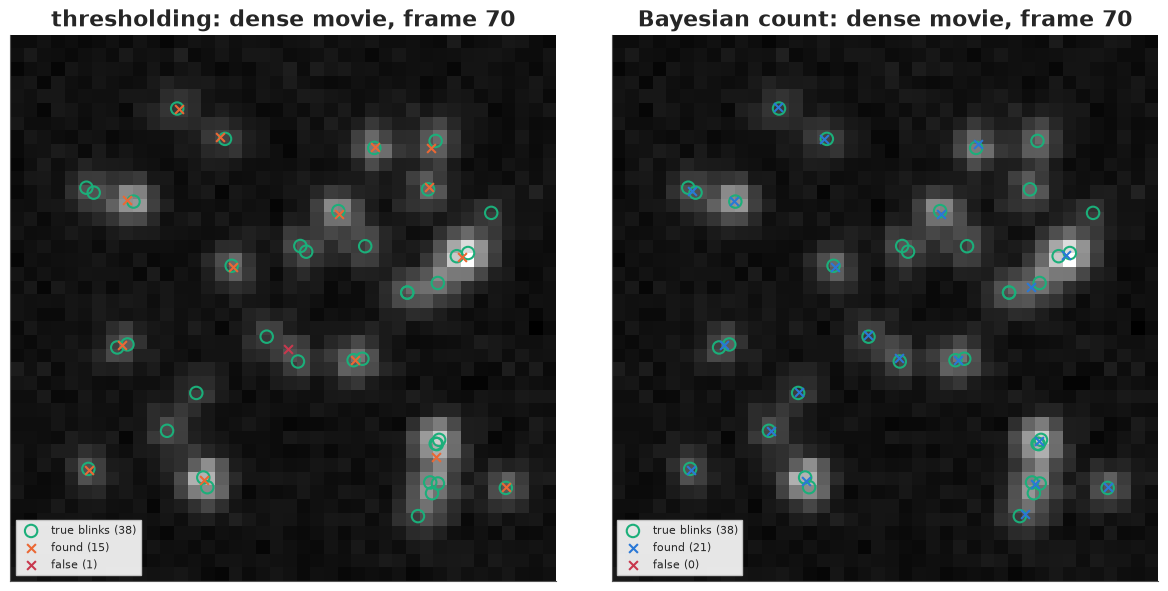

In [14]:
d = movies["dense"]
t_show = d["frame_t"]
fig, axs = plt.subplots(1, 2, figsize=(12, 5.8))
for ax, key, title, col in [(axs[0], "thr", "thresholding", ORANGE), (axs[1], "bay", "Bayesian count", BLUE)]:
    ax.imshow(2 * d["frame"], cmap="gray")
    tru = mols[ev_mol[d["ev_t"] == t_show], 1:3]
    ax.scatter(tru[:, 0], tru[:, 1], s=80, facecolors="none", edgecolors=AQUA, lw=1.5, label=f"true blinks ({len(tru)})")
    res_ = d[key]
    sel = res_[0] == t_show
    mm = d["m_thr"] if key == "thr" else d["m_bay"]
    ok = mm[3][sel] >= 0
    ax.scatter(res_[1][sel][ok, 0], res_[1][sel][ok, 1], marker="x", s=40, color=col, label=f"found ({ok.sum()})")
    ax.scatter(res_[1][sel][~ok, 0], res_[1][sel][~ok, 1], marker="x", s=40, color=RED, label=f"false ({(~ok).sum()})")
    ax.set(title=f"{title}: dense movie, frame {t_show}", xticks=[], yticks=[], xlim=(-0.5, H_SIM - 0.5), ylim=(H_SIM - 0.5, -0.5))
    ax.legend(fontsize=8, loc="lower left", frameon=True, facecolor="white", framealpha=0.9);

In the **sparse movie** 87% of blobs hold one emitter, and both pipelines find most blinks:
thresholding has recall 0.93 and precision 0.98, the Bayesian count recall 0.97 and precision 0.91.
The Bayesian pipeline pays for its extra recall with false detections (the faint extra emitters
of section 5). Localisation accuracy is the same (median error about 12 nm), and both sets of
Laplace error bars are close to calibrated (87-88% coverage of nominal 90%).

In the **dense movie** (18 blinks per frame) thresholding loses almost half the blinks (recall
0.53): overlapping spots become one detection. The Bayesian count recovers 0.76 of them at
precision 0.88. Its localisations are also more honest: 80% of its 90% intervals cover the truth,
against 66% for thresholding, whose single-emitter fits of merged blobs sit between two molecules
while reporting a single molecule's error bar. In the frame shown (38 true blinks), thresholding
finds 15 and the Bayesian count 21. Neither finds the pairs that blink in the same pore at the same
time (tens of nanometres apart): as section 5 showed, no method can separate those from one
frame. The cap of $K = 4$ also binds in 258 dense blobs. Running the experiment sparsely remains
the best cure; the Bayesian count widens what "sparse enough" means.

## 7 · From localisations to an image, with uncertainty

A super-resolved image is a density estimate of the point cloud. The simplest is a **histogram**
on a fine grid (here 8 nm pixels). Better is to draw each localisation as a Gaussian whose width is
its own error bar - the Laplace posterior sd from the fitter - so that precise localisations are
sharp and imprecise ones are faint smudges instead of misleading points. We render the sparse
movie's Bayesian localisations, dropping those with an error bar above 30 nm (a common quality
filter), and compare with the truth.

How sharp is the result? **Fourier ring correlation** (FRC; Nieuwenhuizen et al. 2013) splits the
localisations into two halves, renders each, and correlates their Fourier transforms ring by
ring; the resolution is the inverse of the spatial frequency where the correlation drops below
1/7. We split by blocks of 50 frames.

In [15]:
def render(xy_px, sd_nm, px_nm=8.0, fov_px=H_SIM, gaussian=True):
    """Image on a px_nm grid: each localisation a normalised Gaussian of its own sd (or a histogram)."""
    n_ = int(round(fov_px * PX / px_nm))
    xy = (xy_px + 0.5) * PX / px_nm
    if not gaussian:
        img, _, _ = np.histogram2d(xy[:, 1], xy[:, 0], bins=n_, range=[[0, n_], [0, n_]])
        return img
    img = np.zeros((n_, n_))
    s = np.maximum(sd_nm / px_nm, 0.5)
    for sc in np.unique(np.round(s * 2) / 2):                 # group by sd for speed
        sel = np.round(s * 2) / 2 == sc
        h, _, _ = np.histogram2d(xy[sel, 1], xy[sel, 0], bins=n_, range=[[0, n_], [0, n_]])
        img += ndi.gaussian_filter(h, sc)
    return img


def frc(xy1, xy2, px_nm=5.0, fov_px=H_SIM):
    n_ = int(round(fov_px * PX / px_nm))
    ims = [np.histogram2d((q[:, 1] + 0.5) * PX / px_nm, (q[:, 0] + 0.5) * PX / px_nm, bins=n_,
                          range=[[0, n_], [0, n_]])[0] for q in (xy1, xy2)]
    win = np.outer(np.hanning(n_), np.hanning(n_))
    F1, F2 = (np.fft.fftshift(np.fft.fft2(im * win)) for im in ims)
    ky, kx = np.indices((n_, n_)) - n_ // 2
    r = np.hypot(kx, ky).astype(int)
    num = np.bincount(r.ravel(), (F1 * F2.conj()).real.ravel())
    den = np.sqrt(np.bincount(r.ravel(), (np.abs(F1) ** 2).ravel()) * np.bincount(r.ravel(), (np.abs(F2) ** 2).ravel()))
    q = np.arange(len(num)) / (n_ * px_nm)                    # cycles per nm
    return q[1:n_ // 2], (num / den)[1:n_ // 2]


sp = movies["sparse"]
t_b, xy_b, sd_b, N_b = sp["bay"][:4]
good = sd_b * PX < 30
print(f"sparse movie: {len(xy_b)} Bayesian localisations, {good.sum()} with sd < 30 nm; "
      f"median sd {np.median(sd_b[good] * PX):.1f} nm")
img_hist = render(xy_b[good], sd_b[good] * PX, gaussian=False)
img_gauss = render(xy_b[good], sd_b[good] * PX)
half = (t_b // 50) % 2 == 0
q, f = frc(xy_b[good & half], xy_b[good & ~half])
below = np.nonzero(f < 1 / 7)[0]
res_frc = 1 / q[below[0]] if len(below) else np.nan
print(f"FRC resolution (1/7 threshold): {res_frc:.0f} nm")

sparse movie: 4836 Bayesian localisations, 4237 with sd < 30 nm; median sd 10.0 nm


FRC resolution (1/7 threshold): 32 nm


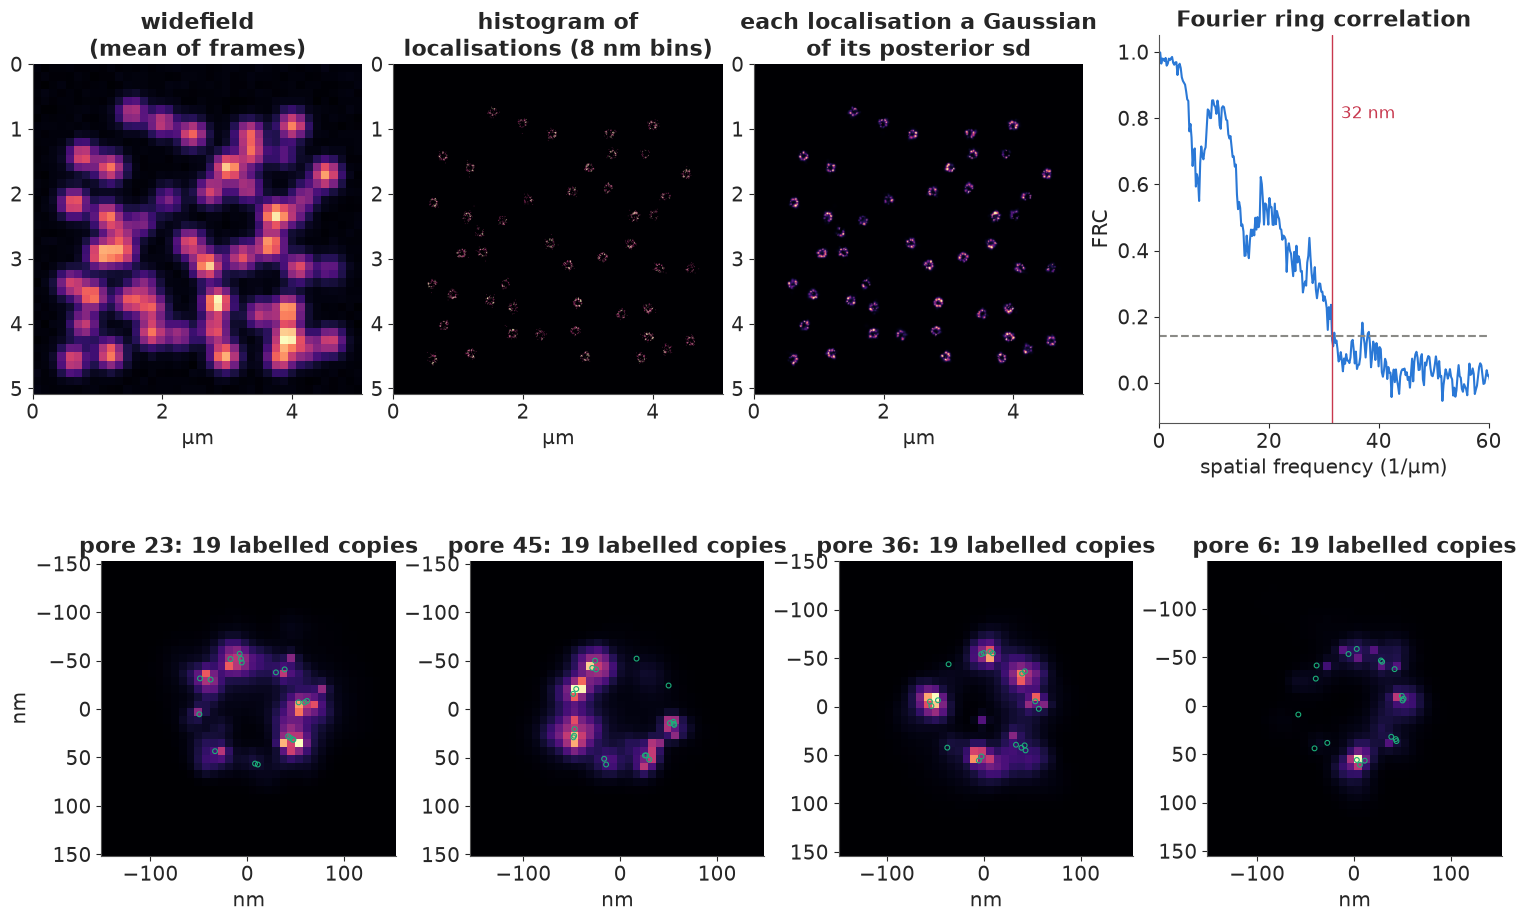

In [16]:
fig = plt.figure(figsize=(15, 9.2))
top, bot = fig.subfigures(2, 1, height_ratios=[1.1, 1])
axs = top.subplots(1, 4)
n_img = img_gauss.shape[0]
ext = [0, H_SIM * PX / 1000, H_SIM * PX / 1000, 0]
axs[0].imshow(2 * np.mean(make_movie(200, np.random.default_rng(0))[0], axis=0), cmap="magma",
              extent=[0, H_SIM * PX / 1000, H_SIM * PX / 1000, 0])
axs[0].set(title="widefield\n(mean of frames)", xlabel="µm")
axs[1].imshow(img_hist, cmap="magma", extent=ext, vmax=np.quantile(img_hist[img_hist > 0], 0.9))
axs[1].set(title="histogram of\nlocalisations (8 nm bins)", xlabel="µm")
axs[2].imshow(img_gauss, cmap="magma", extent=ext, vmax=np.quantile(img_gauss, 0.999))
axs[2].set(title="each localisation a Gaussian\nof its posterior sd", xlabel="µm")
ax = axs[3]
ax.plot(q * 1000, f, color=BLUE)
ax.axhline(1 / 7, color=GREY, ls="--")
ax.axvline(1000 / res_frc, color=RED, lw=1)
ax.text(1000 / res_frc * 1.05, 0.8, f"{res_frc:.0f} nm", color=RED)
ax.set(xlabel="spatial frequency (1/µm)", ylabel="FRC", title="Fourier ring correlation", xlim=(0, 60))
# zoom on four pores
axs = bot.subplots(1, 4)
zoom_ids = np.argsort(np.abs(M_TRUE - np.median(M_TRUE)))[:4]
for ax, pid in zip(axs, zoom_ids):
    c = pores[pid]
    r0_, c0_ = int(round((c[1] + 0.5 - 1.2) * PX / 8)), int(round((c[0] + 0.5 - 1.2) * PX / 8))
    w_ = int(round(2.4 * PX / 8))
    sub = img_gauss[r0_:r0_ + w_, c0_:c0_ + w_]
    x0_, y0_ = c0_ * 8 - (c[0] + 0.5) * PX, r0_ * 8 - (c[1] + 0.5) * PX       # nm, relative to the pore centre
    e_ = [x0_, x0_ + w_ * 8, y0_ + w_ * 8, y0_]
    ax.imshow(sub, cmap="magma", extent=e_)
    mp = mols[mols[:, 0] == pid]
    ax.scatter((mp[:, 1] - c[0]) * PX, (mp[:, 2] - c[1]) * PX, s=12, facecolors="none", edgecolors=AQUA, lw=0.8)
    ax.set(title=f"pore {pid}: {M_TRUE[pid]} labelled copies", xlabel="nm")
axs[0].set_ylabel("nm");

The widefield image (top left) is a blur in which no pore can be told from its neighbours. The
histogram of localisations shows the rings but is speckled and faint: most 8 nm bins hold zero or
one point. Drawing each localisation as a Gaussian of its own posterior sd gives a smooth image in
which the rings are clear. The zooms (bottom) show the eightfold structure: localisations pile
up at the corners that carry labelled copies (green circles), and corners without a labelled copy
stay dark - labelling efficiency, not resolution, is what makes these rings incomplete. FRC gives
a resolution of about 32 nm, three times the median localisation error (10 nm). The pore corners
are about 42 nm apart, so they are just resolved, as the zooms show. FRC should be read with care:
the same molecule blinks in both halves, which correlates them, and FRC measures how
reproducible the point cloud is, not whether it is correct.

The same pipeline runs on the real recording. The truth is unknown there, so we can only look.
One lesson from running the count model on real frames first:

In [17]:
t0 = time.time()
real_res = bayes_pipeline(z_real, lab_real, n_real, LOGB_REAL)
t_r, xy_r, sd_r, N_r, K_r, Kof_r, blob_r = real_res
print(f"real movie: {n_real} blobs -> K counts {np.bincount(K_r, minlength=5)} ({time.time() - t0:.0f} s)")
bright_q = np.quantile(amp, [0, 0.25, 0.5, 0.75, 1.0])
for lo_, hi_ in zip(bright_q[:-1], bright_q[1:]):
    s = (amp >= lo_) & (amp <= hi_)
    print(f"blob amplitude {lo_:6.0f}-{hi_:6.0f}: share with K >= 2 = {np.mean(K_r[s] >= 2):.2f}")
# the extra emitters of K >= 2 blobs: how bright, and how far from the blob's brightest emitter?
ratio, dist = [], []
for b_ in np.unique(blob_r[Kof_r >= 2]):
    j = np.nonzero(blob_r == b_)[0]
    top = j[np.argmax(N_r[j])]
    for o in j[j != top]:
        ratio.append(N_r[o] / N_r[top])
        dist.append(np.hypot(*(xy_r[o] - xy_r[top])) * PX)
print(f"extra emitters: brightness relative to the main one, median {np.median(ratio):.2f} "
      f"(quartiles {np.quantile(ratio, 0.25):.2f}-{np.quantile(ratio, 0.75):.2f}); distance median "
      f"{np.median(dist):.0f} nm (quartiles {np.quantile(dist, 0.25):.0f}-{np.quantile(dist, 0.75):.0f} nm)")
sim_multi = np.mean(movies["sparse"]["bay"][4] >= 2)
print(f"for comparison, share of K >= 2 blobs in the simulated sparse movie: {sim_multi:.2f}")
good_r = sd_r * PX < 30
print(f"{len(xy_r)} localisations; {good_r.sum()} with sd < 30 nm; median sd {np.median(sd_r[good_r]) * PX:.1f} nm; "
      f"median brightness {np.median(N_r[good_r]):.0f} photons")

real movie: 4192 blobs -> K counts [  15 2022  930  440  785] (24 s)
blob amplitude     17-    36: share with K >= 2 = 0.21
blob amplitude     36-    88: share with K >= 2 = 0.31
blob amplitude     88-   194: share with K >= 2 = 0.61
blob amplitude    194-  1701: share with K >= 2 = 0.93
extra emitters: brightness relative to the main one, median 0.12 (quartiles 0.06-0.41); distance median 367 nm (quartiles 301-462 nm)
for comparison, share of K >= 2 blobs in the simulated sparse movie: 0.13
8342 localisations; 4506 with sd < 30 nm; median sd 9.5 nm; median brightness 2328 photons


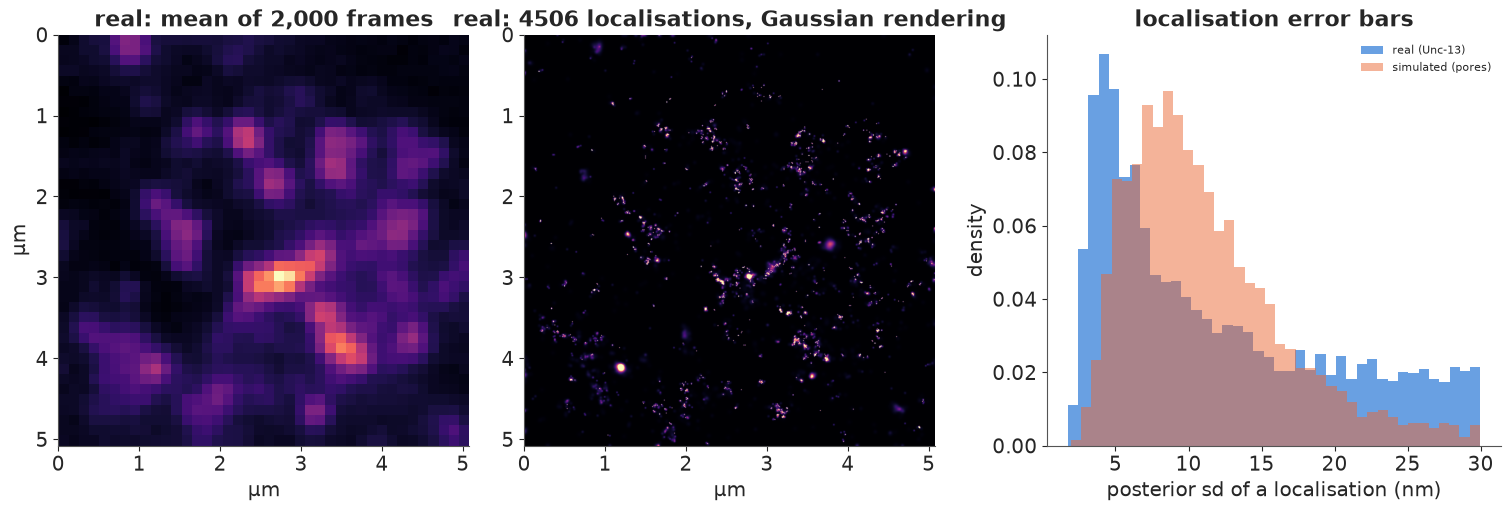

In [18]:
img_real = render(xy_r[good_r], sd_r[good_r] * PX)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(2 * np.mean(z_real, axis=0), cmap="magma", extent=ext)
axs[0].set(title="real: mean of 2,000 frames", xlabel="µm", ylabel="µm")
axs[1].imshow(img_real, cmap="magma", extent=ext, vmax=np.quantile(img_real, 0.998))
axs[1].set(title=f"real: {good_r.sum()} localisations, Gaussian rendering", xlabel="µm")
ax = axs[2]
ax.hist(sd_r[good_r] * PX, bins=40, color=BLUE, alpha=0.7, density=True, label="real (Unc-13)")
ax.hist(sd_b[good] * PX, bins=40, color=ORANGE, alpha=0.5, density=True, label="simulated (pores)")
ax.set(xlabel="posterior sd of a localisation (nm)", ylabel="density", title="localisation error bars")
ax.legend(fontsize=8);

On the real movie the model chooses two or more emitters for 51% of blobs, against 13% in the
simulated sparse movie, and the share rises steeply with brightness (21% of the dimmest quarter
of blobs, 93% of the brightest). The extra emitters are faint (a median of 12% of the main
emitter's brightness) and far from it (a median of 370 nm): not a second molecule hidden under
the spot, but faint signal around it. Out-of-focus molecules, background that is not flat in a
tissue sample, and PSF wings that are heavier than a Gaussian's all produce such signal, and a
model with an in-focus Gaussian PSF on a flat background can explain it only with extra emitters.
**The evidence is only as good as the forward model**: at 2,000 photons the data easily reject a
slightly wrong model, and the count posterior then reflects the misfit, not the number of
molecules. The fixes are a better forward model (a PSF measured from bead stacks, a locally
varying background), or a prior that makes faint emitters expensive. For the image, the damage is
limited: the extra emitters have large error bars, and the 30 nm quality filter keeps 4,506 of the
8,342 localisations (median error bar 9.5 nm, median brightness about 2,300 photons).

The rendering turns the diffraction-limited blobs of the mean image into clusters of Unc-13
localisations a few hundred nanometres across, the active zones of the synapse, with denser
sub-clusters inside (Dannhäuser et al. report Unc-13 subclusters about 26 nm across). Only 2,000
of the 15,000 frames are used here, so the clusters are sparsely sampled. The error-bar
histograms (right) show that the real localisations have both more very precise (bright) and
more poor (faint) localisations than the simulation, whose brightness distribution is narrower.

## 8 · Counting molecules from their blinks

Each labelled molecule blinks several times, so a pore with 19 labelled copies might produce 90
localisations. Counting localisations over-counts molecules by the mean number of blinks, and
dividing by that mean (as is common) gives a number without an error bar, which is worse than it
sounds because the number of blinks per molecule is itself very variable. The Bayesian version
(in the spirit of Lee et al. 2012 and Rollins et al. 2015) writes the generative story down:

- pore $i$ has $M_i \sim \text{Binomial}(32, \varepsilon)$ labelled copies ($\varepsilon$ the
  labelling efficiency);
- each copy produces $1 + G$ localisations with $G \sim \text{NegBinomial}(r, p)$ (geometric
  when $r = 1$);
- so pore $i$'s localisation count is $L_i = M_i + \text{NegBinomial}(M_i r, p)$, because a sum
  of $M$ independent NegBinomial$(r, p)$ is NegBinomial$(Mr, p)$.

The integer $M_i$ is summed out exactly with `logsumexp` over 0-32. Blinking statistics are only
weakly identified from pore totals alone, so, as in practice, a **calibration** measurement
informs them: the blink counts of 150 isolated molecules imaged sparsely on the same setup
(simulated here from the same blinking process). The pore counts $L_i$ are the sparse movie's
Bayesian localisations assigned to the nearest pore centre (within 150 nm). We take the pore
centres as known for simplicity; in practice they come from a clustering step.

In [19]:
d_pore = np.hypot(xy_b[:, None, 0] - pores[None, :, 0], xy_b[:, None, 1] - pores[None, :, 1])
near = d_pore.argmin(1)
L_obs = np.bincount(near[d_pore.min(1) < 150 / PX], minlength=len(pores))
calib = 1 + rng6.geometric(1 / (1 + MEAN_EXTRA), 150) - 1
print(f"localisations per pore: {L_obs.min()}-{L_obs.max()} (true blinks per pore: "
      f"{np.bincount(mols[ev_mol, 0].astype(int), minlength=len(pores)).min()}-"
      f"{np.bincount(mols[ev_mol, 0].astype(int), minlength=len(pores)).max()}); "
      f"calibration: mean {calib.mean():.2f} localisations per molecule")

M_GRID = np.arange(0, 33)
k_extra = L_obs[:, None] - M_GRID[None, :]                    # extra blinks beyond one per copy
valid = (k_extra >= 0) & ((M_GRID[None, :] > 0) | (L_obs[:, None] == 0))
k_safe = np.where(valid, k_extra, 0)
with pm.Model(coords={"pore": np.arange(len(pores)), "M": M_GRID}) as m_count:
    eps = pm.Beta("eps", 2.0, 2.0)
    r_b = pm.LogNormal("r", 0.0, 1.0)
    mean_extra = pm.LogNormal("mean_extra", np.log(3.0), 1.0)
    p_b = r_b / (r_b + mean_extra)
    pm.NegativeBinomial("calib", n=r_b, p=p_b, observed=calib - 1)
    n_tot = pt.maximum(M_GRID * r_b, 1e-6)[None, :]
    lp_nb = (pt.gammaln(k_safe + n_tot) - pt.gammaln(n_tot) - gammaln(k_safe + 1)
             + n_tot * pt.log(p_b) + k_safe * pt.log1p(-p_b))
    lp_nb = pt.where(M_GRID[None, :] == 0, 0.0, lp_nb)
    lp_M = pm.logp(pm.Binomial.dist(32, eps), M_GRID)[None, :]
    lp = pt.where(valid, lp_M + lp_nb, -np.inf)
    pm.Potential("pores", pt.logsumexp(lp, axis=1).sum())
    idata_count = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"divergences: {int(idata_count.sample_stats['diverging'].sum())}")
az.summary(idata_count, var_names=["eps", "r", "mean_extra"], round_to=3)

localisations per pore: 40-166 (true blinks per pore: 37-155); calibration: mean 4.86 localisations per molecule


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eps,0.591,0.039,0.529,0.656,1323.153,1547.881,1.005,0.001,0.001
r,1.107,0.171,0.861,1.398,2639.440,2340.587,1.001,0.003,0.003
mean_extra,4.171,0.308,3.700,4.693,1378.168,1576.695,1.006,0.008,0.006


In [20]:
pc = az.extract(idata_count, var_names=["eps", "r", "mean_extra"], num_samples=1000, random_seed=RANDOM_SEED)
e_, r_, me_ = (pc[v].values for v in ["eps", "r", "mean_extra"])
p_ = r_ / (r_ + me_)
# posterior of each pore's copy number, averaged over the parameter draws (Rao-Blackwellised)
post_M = np.zeros((len(pores), len(M_GRID)))
for e1, r1, p1 in zip(e_, r_, p_):
    lpm = binom.logpmf(M_GRID, 32, e1)[None, :] + np.where(
        M_GRID[None, :] == 0, np.where(L_obs[:, None] == 0, 0.0, -np.inf),
        nbinom.logpmf(k_safe, np.maximum(M_GRID * r1, 1e-9)[None, :], p1))
    lpm = np.where(valid, lpm, -np.inf)
    w_ = np.exp(lpm - lpm.max(1, keepdims=True))
    post_M += w_ / w_.sum(1, keepdims=True)
post_M /= len(e_)
cdf = post_M.cumsum(1)
M_mean = post_M @ M_GRID
M_lo, M_hi = (cdf >= 0.05).argmax(1), (cdf >= 0.95).argmax(1)
naive = L_obs / calib.mean()
cover = np.mean((M_TRUE >= M_lo) & (M_TRUE <= M_hi))
print(f"labelling efficiency: posterior mean {e_.mean():.2f}, 90% interval {np.quantile(e_, 0.05):.2f}-"
      f"{np.quantile(e_, 0.95):.2f} (true 0.60)")
print(f"copies per pore: RMSE Bayesian {np.sqrt(np.mean((M_mean - M_TRUE) ** 2)):.1f}, "
      f"naive L/mean {np.sqrt(np.mean((naive - M_TRUE) ** 2)):.1f}; raw localisation count over-counts by "
      f"{np.mean(L_obs / M_TRUE):.1f}x; 90% intervals cover the truth for {cover:.0%} of pores; "
      f"mean interval width {np.mean(M_hi - M_lo):.1f} copies")

labelling efficiency: posterior mean 0.59, 90% interval 0.53-0.66 (true 0.60)
copies per pore: RMSE Bayesian 2.0, naive L/mean 4.5; raw localisation count over-counts by 5.0x; 90% intervals cover the truth for 96% of pores; mean interval width 8.1 copies


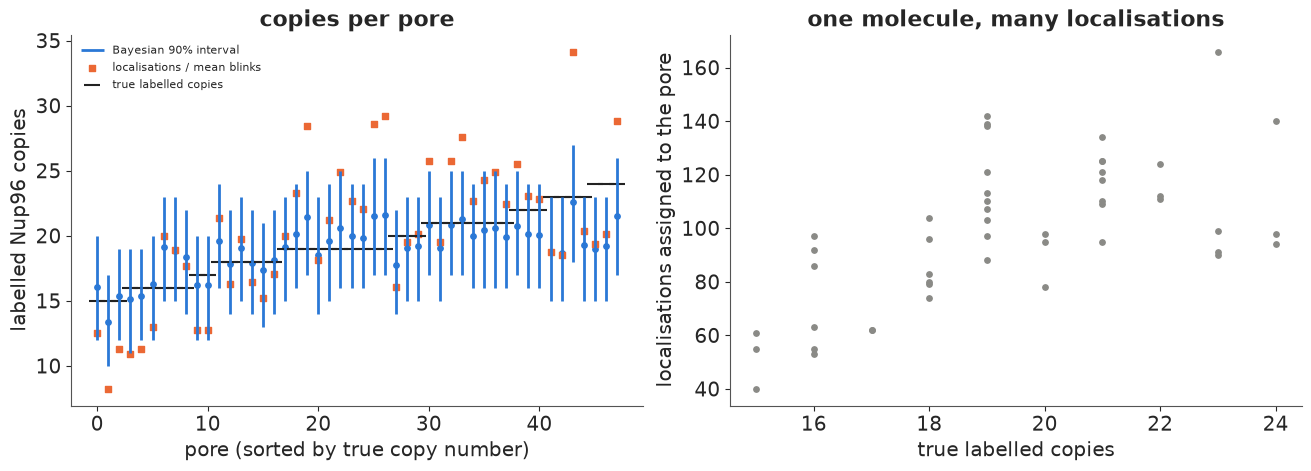

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axs[0]
order = np.argsort(M_TRUE + 0.01 * np.arange(len(pores)))
xpos = np.arange(len(pores))
ax.vlines(xpos, M_lo[order], M_hi[order], color=BLUE, lw=2, label="Bayesian 90% interval")
ax.scatter(xpos, M_mean[order], color=BLUE, s=15)
ax.scatter(xpos, naive[order], color=ORANGE, marker="s", s=15, label="localisations / mean blinks")
ax.scatter(xpos, M_TRUE[order], color=INK, marker="_", s=120, label="true labelled copies")
ax.set(xlabel="pore (sorted by true copy number)", ylabel="labelled Nup96 copies", title="copies per pore")
ax.legend(fontsize=8)
ax = axs[1]
ax.scatter(M_TRUE, L_obs, color=GREY, s=15)
ax.set(xlabel="true labelled copies", ylabel="localisations assigned to the pore",
       title="one molecule, many localisations");

No divergences and r_hat at most 1.006. The labelling efficiency is recovered (0.59, 90%
interval 0.53-0.66, truth 0.60), and so are the blinking statistics: $r = 1.11$ (a geometric
distribution has $r = 1$) and a mean of 4.2 extra localisations per molecule (truth 4).

The pores produce 40-166 localisations for 15-24 labelled copies: counting localisations
over-counts molecules five-fold, and the scatter (right) shows how loosely the two are related.
Dividing by the calibrated mean number of blinks removes the bias but not the scatter: its
error is 4.5 copies (RMSE). The Bayesian copy numbers have an error of 2.0 copies, because they
combine each pore's count with what the other 47 pores say about labelling (the binomial prior
pulls extreme counts towards the population) and with the known spread of blinking. Their 90%
intervals cover the truth for 96% of pores, and they are wide - about 8 copies. That width is the
honest answer: with a geometric number of blinks per molecule (sd about equal to the mean), a
single pore's localisation count cannot pin its copy number down to better than a few molecules,
however carefully each spot is fitted. The population quantity, the labelling efficiency, is
known to about ±0.04 from 48 pores. The pore counts also carry the pipeline's own errors (missed
blinks, false detections), which the model absorbs without being told about them.

## Summary

- **Super-resolution is inference.** STORM/PALM turn a diffraction-limited image into many
  sparse frames; every step - localisation, detection, reconstruction, counting - is an estimate
  whose uncertainty can be stated.
- **The camera is part of the model.** An EMCCD at high gain behaves like a photon counter that
  discards half the photons; its gain and offset can be read off the photon-transfer curve of the
  data. Ignoring the excess noise makes error bars $\sqrt 2$ too small (73-79% coverage of nominal
  90%) (sections 1-2, 4).
- **Localisation** with a pixel-integrated Gaussian PSF and a Poisson likelihood reaches the
  Cramér-Rao bound and Mortensen's formula; least squares has 15-25% larger errors at low
  background and almost the same at high background. A real spot with about 2,200 photons is localised to
  7 nm, and the Laplace approximation reproduces the NUTS posterior (sections 3-4).
- **Detection is model selection.** Laplace-approximated evidences agree with SMC and cost
  milliseconds. The Bayesian count separates two molecules 190 nm apart 82% of the time, where
  local-maximum thresholding needs about 500 nm; in a dense movie it recovers 76% of blinks
  against 53%, at the price of more false detections (sections 5-6).
- **Reconstruction** as a sum of Gaussians with each localisation's posterior sd shows structures
  (pore corners 42 nm apart) that a histogram only hints at; FRC puts the resolution near 32 nm
  (section 7).
- **Model misfit masquerades as molecules.** On real tissue frames the count model adds faint
  emitters around bright spots: the evidence is only as good as the PSF and background model
  (section 7).
- **Counting** molecules from blinking clusters needs a model of blinking: a negative-binomial
  blink count with the copy number summed out recovers the labelling efficiency and gives
  calibrated per-pore copy numbers, twice as accurate as dividing by the mean number of blinks
  (section 8).

## Try it yourself

1. **A better forward model for the real data.** Replace the flat background by a plane
   ($b_0 + b_x x + b_y y$) and let each emitter have its own PSF width (defocus). How much does the
   share of real blobs with $K \ge 2$ fall? Then compare the evidence of the Gaussian PSF with a
   Moffat or a two-Gaussian PSF on the brightest isolated real spots.
2. **A prior on the number of emitters.** Replace the flat prior on $K$ by a Poisson prior whose
   mean is the expected number of molecules per blob (estimate it from the movie, hierarchically).
   Redo the recall/precision table for the dense movie, and trace the trade-off between false and
   missed detections as you vary the prior mean.
3. **Counting with long-lived blinks.** Real fluorophores stay on for several frames, so one
   blink gives several localisations in consecutive frames. Simulate on-times with a geometric
   duration, merge localisations that are close in space and consecutive in time (as most
   software does), and extend the counting model so that it stays calibrated. How much does the
   precision of the copy number improve if you also model the photon count of each blink?